# Reproducing a CVPR Paper: Distilled Datamodel with Reverse Gradient Matching
## Reproduction Level 5


### Paper Link: 
https://openaccess.thecvf.com/content/CVPR2024/html/Ye_Distilled_Datamodel_with_Reverse_Gradient_Matching_CVPR_2024_paper.html

Let's dive in and get started! 🚀

# Overview of the Paper

Distilled Data Model (DDM) is introduced in this paper. It discovers how training data affects a model that has already been trained. DDM uses a tiny synthetic collection of samples (synset), instead of expensive retraining. In the offline phase, the synset is created via reverse gradient matching. During the online phase, the synset facilitates the rapid approximation of the impact of data removal on the model. This provides an attribution matrix that shows how each data cluster contributed to the predictions. Experiments demonstrate that DDM performs as well as retraining but is considerably faster.

## What It's About

- **The Challenge:**
State-of-the-art AI models need huge amounts of training data. In order to calculate how much a single sample affects the model, one would usually remove a sample and train the model again. But performing this for every sample takes too much time and processing power.

- **The Idea:**
The paper proposes a method known as the **Distilled Datamodel (DDM)**. Instead of retraining the model every time, it works in two stages:

1. **Offline Training:**
During training the model, the technique forms an extremely small synthetic data set known as a **synset**. The synset maintains important information about the effect of training data on the model. The major technique used here is referred to as **reverse gradient matching**.

2. **Online Evaluation:**
After we have trained the model and geenrated the synset, it is straightforward for us to study the effect of removing some of the training data. This will allow us to simulate data removal without having to retrain the entire model from the beginning. This save both time and computational resources.

- **Why It's Useful:**
  - It saves enormous time and computation.
  - It is simpler to identify which training examples are most important.
  - It also protects the privacy of the original data by using a synthetic replica that does not disclose evident details of the true images.

Generally, this paper offers a useful method of establishing the impact of training data on the action of a model without the excessive cost of repeated retraining.



## The framework of the proposed distilled datamodel from the paper
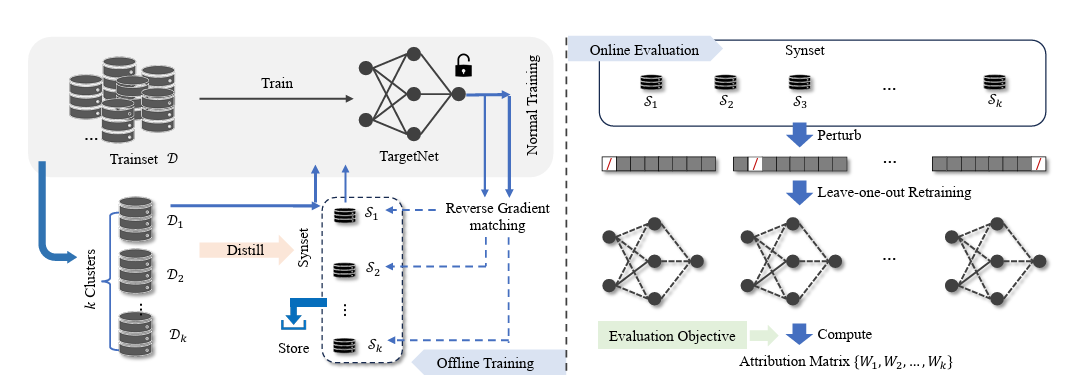

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import Ridge
import numpy as np
from sklearn.cluster import KMeans
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import copy
import torchvision.models as models
import pandas as pd
import timm
import gc
from sklearn.metrics import accuracy_score, classification_report

In [20]:
# ======================
# 1. Configuration
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = 10  # MNIST classes
K = 100           # Total clusters (10 per class for MNIST)
IPC = 1           # Images per cluster
BATCH_SIZE = 64
NUM_EPOCHS = 20    # Full dataset training epochs
DISTILL_STEPS = 350  # Reverse gradient matching steps
LEARNING_RATE = 0.01
LEARNING_RATE_SYN = 10  # For synthetic data optimization
S_STEP_MAX = 5           # Max trajectory step


Using device: cuda


# Download MNIST Training Dataset

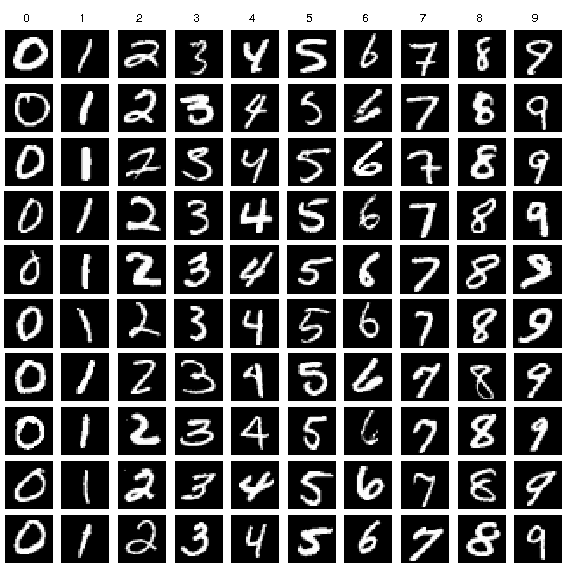

In [21]:
# ======================
# 2. Data Preparation
# ======================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
print("Total training samples:", len(train_set)) 

Total training samples: 60000


# Initial Model Training and Evaluation

**Training Phase:**  
- **ConvNet Training:** We train our model on the full dataset using a **ConvNet** architecture.  
- **Gradient Tracking:** During training, we collect gradient trajectories, which are essential for generating the synset dataset.  
- **Time Monitoring:** We track the total training time using GPU resources. 

**Testing Phase:**  
- After training, we evaluate our model's performance on the test dataset.


In [22]:
# ======================
# 3. ConvNet Definition
# ======================
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize the model
model = ConvNet(num_classes=NUM_CLASSES).to(device)

In [23]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print GPU details
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")

# Initialize optimizer and loss function
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
criterion = nn.CrossEntropyLoss()

trajectory = []  # Store model parameters at each epoch
model.train()

# Start time tracking
start_time = time.time()

print("\nTraining the target model on the entire MNIST dataset...")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time() 
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_time = time.time() - epoch_start

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Loss: {avg_loss:.4f} - Time: {epoch_time:.2f}s")

    # Store model parameters
    trajectory.append({k: v.clone().detach().cpu() for k, v in model.state_dict().items()})


torch.save(model.state_dict(), "trained_model.pth")
torch.save(trajectory, "model_trajectory.pth")

# Total training time
total_time = time.time() - start_time

print(f"\nFinished training. Stored {len(trajectory)} checkpoints in the trajectory.")
print(f"Total Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

# Print final GPU memory usage
if torch.cuda.is_available():
    print(f"Final GPU Memory Allocated: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
    print(f"Final GPU Memory Cached: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")


Using GPU: Tesla T4
Memory Allocated: 204.35 MB
Memory Cached: 244.00 MB

Training the target model on the entire MNIST dataset...
Epoch [1/20] - Loss: 0.2014 - Time: 13.96s
Epoch [2/20] - Loss: 0.0508 - Time: 13.77s
Epoch [3/20] - Loss: 0.0361 - Time: 13.75s
Epoch [4/20] - Loss: 0.0264 - Time: 13.58s
Epoch [5/20] - Loss: 0.0205 - Time: 13.73s
Epoch [6/20] - Loss: 0.0146 - Time: 13.63s
Epoch [7/20] - Loss: 0.0121 - Time: 13.78s
Epoch [8/20] - Loss: 0.0109 - Time: 13.64s
Epoch [9/20] - Loss: 0.0072 - Time: 13.74s
Epoch [10/20] - Loss: 0.0063 - Time: 13.75s
Epoch [11/20] - Loss: 0.0051 - Time: 13.59s
Epoch [12/20] - Loss: 0.0041 - Time: 13.80s
Epoch [13/20] - Loss: 0.0025 - Time: 13.53s
Epoch [14/20] - Loss: 0.0020 - Time: 13.56s
Epoch [15/20] - Loss: 0.0016 - Time: 13.59s
Epoch [16/20] - Loss: 0.0010 - Time: 13.65s
Epoch [17/20] - Loss: 0.0005 - Time: 13.69s
Epoch [18/20] - Loss: 0.0003 - Time: 13.55s
Epoch [19/20] - Loss: 0.0002 - Time: 13.59s
Epoch [20/20] - Loss: 0.0003 - Time: 13.57

Total test samples: 10000

Test Accuracy: 99.35%
Average Test Loss: 0.0302

Classification Report:
               precision    recall  f1-score   support

           0     0.9939    0.9969    0.9954       980
           1     0.9965    0.9956    0.9960      1135
           2     0.9951    0.9932    0.9942      1032
           3     0.9951    0.9970    0.9960      1010
           4     0.9909    0.9939    0.9924       982
           5     0.9899    0.9933    0.9916       892
           6     0.9969    0.9937    0.9953       958
           7     0.9932    0.9922    0.9927      1028
           8     0.9918    0.9908    0.9913       974
           9     0.9911    0.9881    0.9896      1009

    accuracy                         0.9935     10000
   macro avg     0.9934    0.9935    0.9934     10000
weighted avg     0.9935    0.9935    0.9935     10000



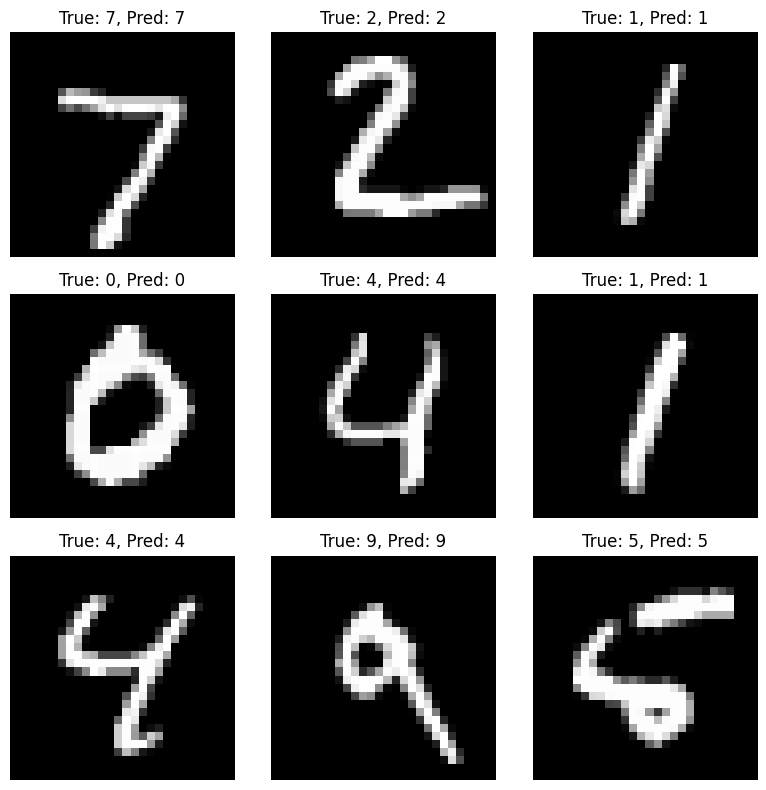

In [24]:
# Load Test Data
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print("Total test samples:", len(test_set))  # Should be 10,000


# Set model to evaluation mode
model.eval()

# Lists to store predictions and ground truth labels
all_preds = []
all_labels = []
total_test_loss = 0

# Disable gradient calculation for inference
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        total_test_loss += loss.item()

        _, predicted = torch.max(outputs, 1) 
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute Average Test Loss
avg_test_loss = total_test_loss / len(test_loader)

# Compute Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Generate Classification Report
class_report = classification_report(all_labels, all_preds, digits=4)

# Print Results
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Average Test Loss: {avg_test_loss:.4f}")
print("\nClassification Report:\n", class_report)

# Plot some predictions
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

for i in range(9):
    img, label = test_set[i]  # Corrected from test_dataset to test_set
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, predicted_label = torch.max(output, 1)

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"True: {label}, Pred: {predicted_label.item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Algorithm 1: The Proposed DDM Framework

## **Offline Training Step**

**Input:**  
- **D:** Training set  
- **M:** Target model  
- **{θ₀, θ₁, ..., θₜ}:** Training trajectory of the target network  
- **s:** Trajectory step  

**Steps:**

1. **Divide Data**  
   Split the training set **D** into **K** clusters.
   
2. **Initialize Synthetic Samples**  
    Randomly initialize **K** synthetic samples, forming the set **S**.
   
3. **Distillation Loop:**  
   For each distillation step:
   - **Select Trajectory Points:**  
     - Choose a random start from the target trajectory: **θₜ** (0 ≤ t < τ).  
     - Choose the end point: **θₜ₊ₛ** (ensuring t + s < τ).
     
   - **For Each Cluster (κ = 1, 2, …, K):**  
     - **Compute Gradients on Real Data:**  
       Calculate **∇L(θₜ; Dₖ)**.
     - **Compute Gradients on Synthetic Data:**  
       Calculate **∇L(θₜ₊ₛ; Sₖ)**.
     - **Update Synthetic Sample:**  
       Minimize the distance between **∇L(θₜ; Dₖ)** and **–∇L(θₜ₊ₛ; Sₖ)** to update **Sₖ**.
       
**Output:**  
- The set of cluster-wise synthetic data: **{S₁, S₂, ..., S_K}**.


In [25]:
# ======================
# 4. Feature Extraction for Clustering
# ======================
def extract_features(model, data_loader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device)
            conv_output = model.conv_layers(images)
            pooled = F.adaptive_avg_pool2d(conv_output, (1, 1))
            flattened = torch.flatten(pooled, 1)
            features.append(flattened.cpu())
            labels.append(targets)
    return torch.cat(features), torch.cat(labels)

feature_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)
all_features, all_labels = extract_features(model, feature_loader, device)
all_features = all_features.numpy()
all_labels = all_labels.numpy()

In [26]:
# ======================
# 5. Class-Wise Clustering
# ======================
clusters_per_class = 10  # 10 clusters per class
cluster_assignments = np.full(len(all_labels), -1, dtype=int)

for class_idx in range(NUM_CLASSES):
    # Filter features for current class
    class_mask = (all_labels == class_idx)
    class_features = all_features[class_mask]
    
    # Perform K-Means clustering for this class
    kmeans = KMeans(n_clusters=clusters_per_class, random_state=0)
    cluster_ids = kmeans.fit_predict(class_features)
    
    # Assign global cluster IDs 
    global_cluster_ids = class_idx * clusters_per_class + cluster_ids
    cluster_assignments[class_mask] = global_cluster_ids

# Verify clustering
for cls in range(NUM_CLASSES):
    print(f"Class {cls} clusters:", np.unique(cluster_assignments[all_labels == cls]))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Class 0 clusters: [0 1 2 3 4 5 6 7 8 9]
Class 1 clusters: [10 11 12 13 14 15 16 17 18 19]
Class 2 clusters: [20 21 22 23 24 25 26 27 28 29]
Class 3 clusters: [30 31 32 33 34 35 36 37 38 39]
Class 4 clusters: [40 41 42 43 44 45 46 47 48 49]
Class 5 clusters: [50 51 52 53 54 55 56 57 58 59]
Class 6 clusters: [60 61 62 63 64 65 66 67 68 69]
Class 7 clusters: [70 71 72 73 74 75 76 77 78 79]
Class 8 clusters: [80 81 82 83 84 85 86 87 88 89]
Class 9 clusters: [90 91 92 93 94 95 96 97 98 99]


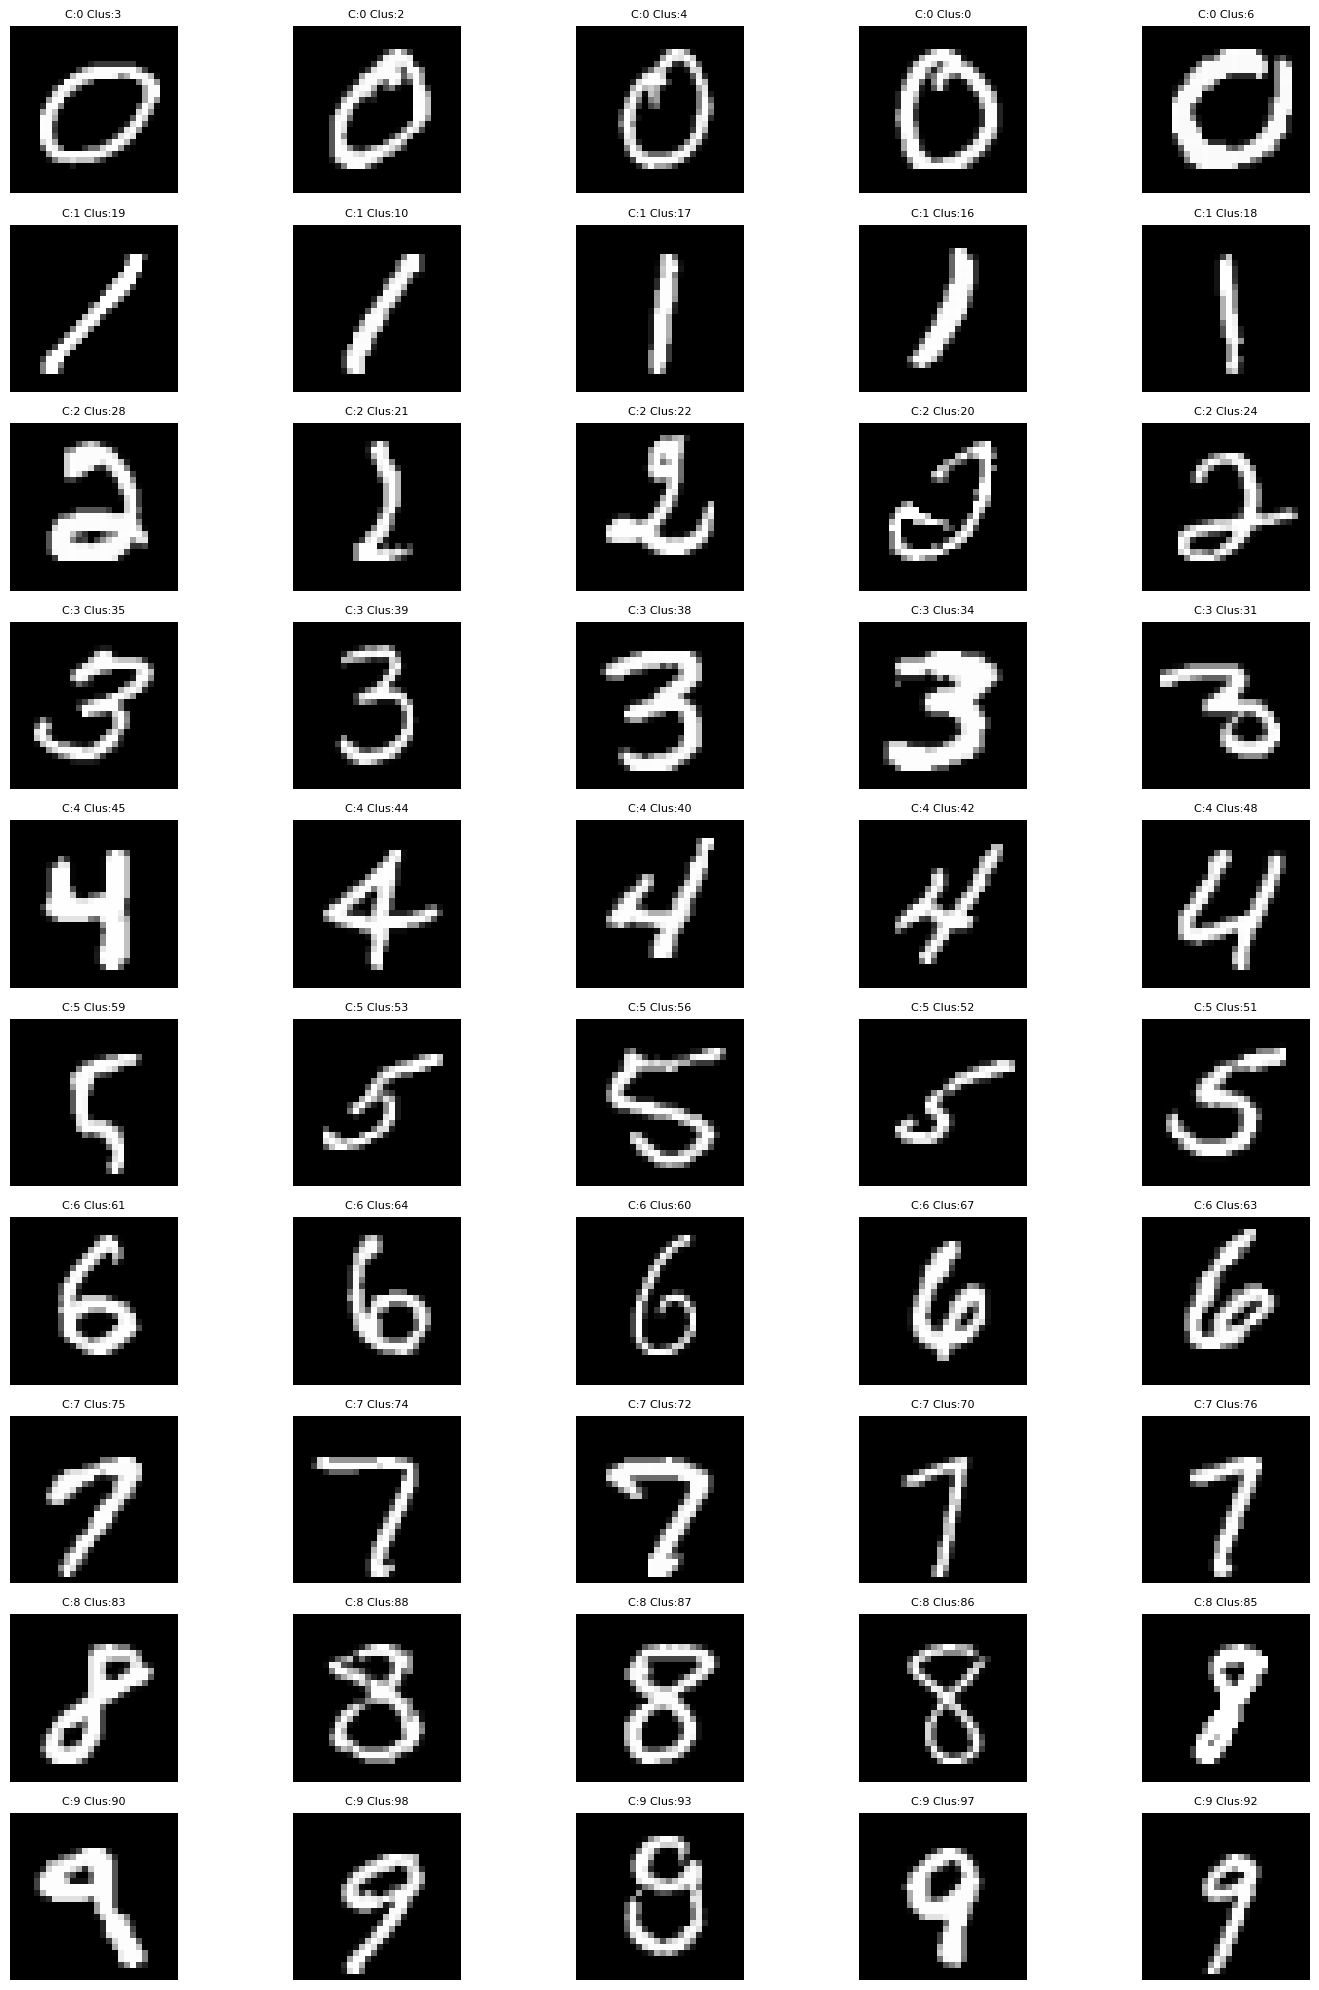

In [27]:
def visualize_class_clusters(num_clusters=5):
    plt.figure(figsize=(15, 20))
    clusters_per_class = 10  # Must match your clustering setup
    
    for class_idx in range(NUM_CLASSES):
        # Get all clusters belonging to this class
        class_clusters = np.arange(class_idx * clusters_per_class, (class_idx + 1) * clusters_per_class)
        
        # Randomly select 5 clusters from this class
        selected_clusters = np.random.choice(class_clusters, num_clusters, replace=False)
        
        # Create subplot row for this class
        for i, cluster_id in enumerate(selected_clusters):
            ax = plt.subplot(NUM_CLASSES, num_clusters, class_idx * num_clusters + i + 1)
            
            # Get first image from cluster
            cluster_indices = np.where(cluster_assignments == cluster_id)[0]
            if len(cluster_indices) > 0:
                img, _ = train_set[cluster_indices[0]] 
                plt.imshow(img.squeeze(), cmap='gray')
                plt.title(f"C:{class_idx} Clus:{cluster_id}", fontsize=8)
            else:
                plt.title(f"Empty Cluster {cluster_id}", fontsize=8)
            
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_class_clusters()

In [28]:
import numpy as np
from collections import Counter

# Count images per cluster
cluster_counts = Counter(cluster_assignments)

# Count images per class
class_counts = Counter(all_labels)

# Display the number of images per cluster
print("\n Images per Cluster:")
for cluster_id, count in sorted(cluster_counts.items()):
    print(f"Cluster {cluster_id}: {count} images")



🔹 Images per Cluster:
Cluster 0: 617 images
Cluster 1: 650 images
Cluster 2: 635 images
Cluster 3: 469 images
Cluster 4: 587 images
Cluster 5: 574 images
Cluster 6: 788 images
Cluster 7: 581 images
Cluster 8: 475 images
Cluster 9: 547 images
Cluster 10: 766 images
Cluster 11: 899 images
Cluster 12: 1022 images
Cluster 13: 130 images
Cluster 14: 572 images
Cluster 15: 526 images
Cluster 16: 599 images
Cluster 17: 1003 images
Cluster 18: 773 images
Cluster 19: 452 images
Cluster 20: 700 images
Cluster 21: 471 images
Cluster 22: 619 images
Cluster 23: 516 images
Cluster 24: 694 images
Cluster 25: 648 images
Cluster 26: 470 images
Cluster 27: 503 images
Cluster 28: 608 images
Cluster 29: 729 images
Cluster 30: 533 images
Cluster 31: 587 images
Cluster 32: 745 images
Cluster 33: 473 images
Cluster 34: 643 images
Cluster 35: 505 images
Cluster 36: 430 images
Cluster 37: 882 images
Cluster 38: 517 images
Cluster 39: 816 images
Cluster 40: 689 images
Cluster 41: 628 images
Cluster 42: 479 ima

In [ ]:
sorted_indices = np.argsort(all_labels)
cluster_assignments_sorted = cluster_assignments[sorted_indices]
cluster_ids_torch = torch.tensor(cluster_assignments_sorted, dtype=torch.long, device=device)
train_data_gpu = torch.stack([train_set[i][0]for i in sorted_indices]).to(device)
train_targets_gpu = torch.tensor([train_set[i][1] for i in sorted_indices], dtype=torch.long, device=device)

In [29]:
DISTILL_STEPS = 350
LEARNING_RATE_SYN = 10  # from paper learning rate set for synset is 10
LEARNING_RATE_MODEL = 0.01
NUM_CLASSES = 10
NUM_CLUSTERS_PER_CLASS = 10
K = NUM_CLASSES * NUM_CLUSTERS_PER_CLASS  # Total clusters

# Class-wise Reverse Gradient Matching
class ReverseGradientSynset(nn.Module):
    def __init__(self, cluster_assignments, train_set, device):
        super().__init__()
        self.device = device
        self.num_clusters = K  

        # Collect real images and labels
        all_images = torch.stack([x[0] for x in train_set]).to(device)
        all_labels = torch.tensor([x[1] for x in train_set]).to(device)
        cluster_assignments = torch.tensor(cluster_assignments).to(device)

        synthetic_images = []
        synthetic_labels = []

        for cluster_id in range(self.num_clusters):
            # Ensure cluster assignment matches the correct label range
            expected_label = cluster_id // NUM_CLUSTERS_PER_CLASS  
            cluster_indices = torch.where((cluster_assignments == cluster_id) & (all_labels == expected_label))[0]

            if len(cluster_indices) == 0:
                print(f"WARNING: Cluster {cluster_id} (Expected Class {expected_label}) is empty!")

            assert len(cluster_indices) > 0, f" ERROR: Cluster {cluster_id} has no valid samples!"

            # Pick a random real image from the correct cluster
            selected_idx = cluster_indices[np.random.randint(0, len(cluster_indices))]

            img = all_images[selected_idx].unsqueeze(0).clone().detach()
            label = all_labels[selected_idx]


            synthetic_images.append(nn.Parameter(img.requires_grad_(True)))  
            synthetic_labels.append(label)

        self.synthetic_images = nn.Parameter(torch.cat(synthetic_images))
        self.synthetic_labels = torch.tensor(synthetic_labels).to(device)

        print("Synthetic dataset initialized successfully with real images!")

    def __len__(self):
        return len(self.synthetic_labels)

In [ ]:
def visualize_clusters(synthetic_images, cluster_labels, step, loss):
    """
    Plots synthetic images for each cluster in each class.
    """
    num_classes = 10  
    num_clusters = synthetic_images.shape[0] // num_classes  

    fig, axes = plt.subplots(num_classes, num_clusters, figsize=(15, 10))
    fig.suptitle(f"Step {step} | Avg Cosine Loss: {loss:.4f}", fontsize=14)

    for cls in range(num_classes):
        for clus in range(num_clusters):
            cluster_idx = cls * num_clusters + clus
            image = synthetic_images[cluster_idx].detach().cpu().numpy().squeeze()

            ax = axes[cls, clus]
            ax.imshow(image, cmap="gray", vmin=0, vmax=1)  # Adjusted range
            ax.axis("off")
            if clus == 0:
                ax.set_title(f"Class {cls}", fontsize=12, loc="left")

    plt.tight_layout()
    plt.show()

In [30]:

# Reverse Gradient Matching Process with Class-wise Clustering
def reverse_gradient_matching(trajectory, cluster_assignments, train_set, device):
    model_s = ConvNet(NUM_CLASSES).to(device)  # Model for θt+s
    model_t = ConvNet(NUM_CLASSES).to(device)  # Model for θt

    # Initialize the synthetic dataset using real images from clusters
    synset = ReverseGradientSynset(cluster_assignments, train_set, device)
    
    optimizer_syn = optim.Adam([synset.synthetic_images], lr=LEARNING_RATE_SYN)
    optimizer_model = optim.SGD(model_t.parameters(), lr=LEARNING_RATE_MODEL)

    for step in range(DISTILL_STEPS):
        t = np.random.randint(0, len(trajectory) - 1)
        s = np.random.randint(1, min(20, len(trajectory) - t))  
        t_s = t + s

        theta_t = trajectory[t]
        theta_t_s = trajectory[t_s]

        # Load model states
        model_t.load_state_dict(theta_t)  
        model_s.load_state_dict(theta_t_s)  

        total_loss = 0

        for k in range(K):
            idx_k = torch.where(cluster_ids_torch == k)[0]
            if len(idx_k) == 0:
                continue  

            real_imgs = train_data_gpu[idx_k]  
            real_lbls = train_targets_gpu[idx_k]  

            # Compute gradients on real data (∇L(θt, Dκ))
            model_t.zero_grad()
            loss_real = F.cross_entropy(model_t(real_imgs), real_lbls)
            grad_real = torch.autograd.grad(loss_real, model_t.parameters(), create_graph=True)

            # Compute gradients on synthetic data (∇L(θt+s, Sκ))
            model_s.zero_grad()
            syn_img_k = synset.synthetic_images[k].unsqueeze(0)
            loss_syn = F.cross_entropy(model_s(syn_img_k), synset.synthetic_labels[k].unsqueeze(0))
            grad_syn = torch.autograd.grad(loss_syn, model_s.parameters(), create_graph=True)

            # Reverse Gradient Matching Loss (Cosine Similarity)
            cluster_loss = sum(1 - F.cosine_similarity(gr.view(-1), -gs.view(-1), dim=0) for gr, gs in zip(grad_real, grad_syn))
            cluster_loss.backward()
            total_loss += cluster_loss.item()

        # Update Synthetic Images
        optimizer_syn.step()
        optimizer_syn.zero_grad()

        # Update Model (θt) Parameters
        optimizer_model.step()
        optimizer_model.zero_grad()

        # Clamp synthetic images to prevent instability
        with torch.no_grad():
            synset.synthetic_images.data = torch.clamp(synset.synthetic_images, 0.0, 1.0)

        # Visualization of Each Class & Its Clusters
        if step % 50 == 0:
            visualize_clusters(synset.synthetic_images, synset.synthetic_labels, step, total_loss / K)

    return synset


Synthetic dataset initialized successfully with real images!


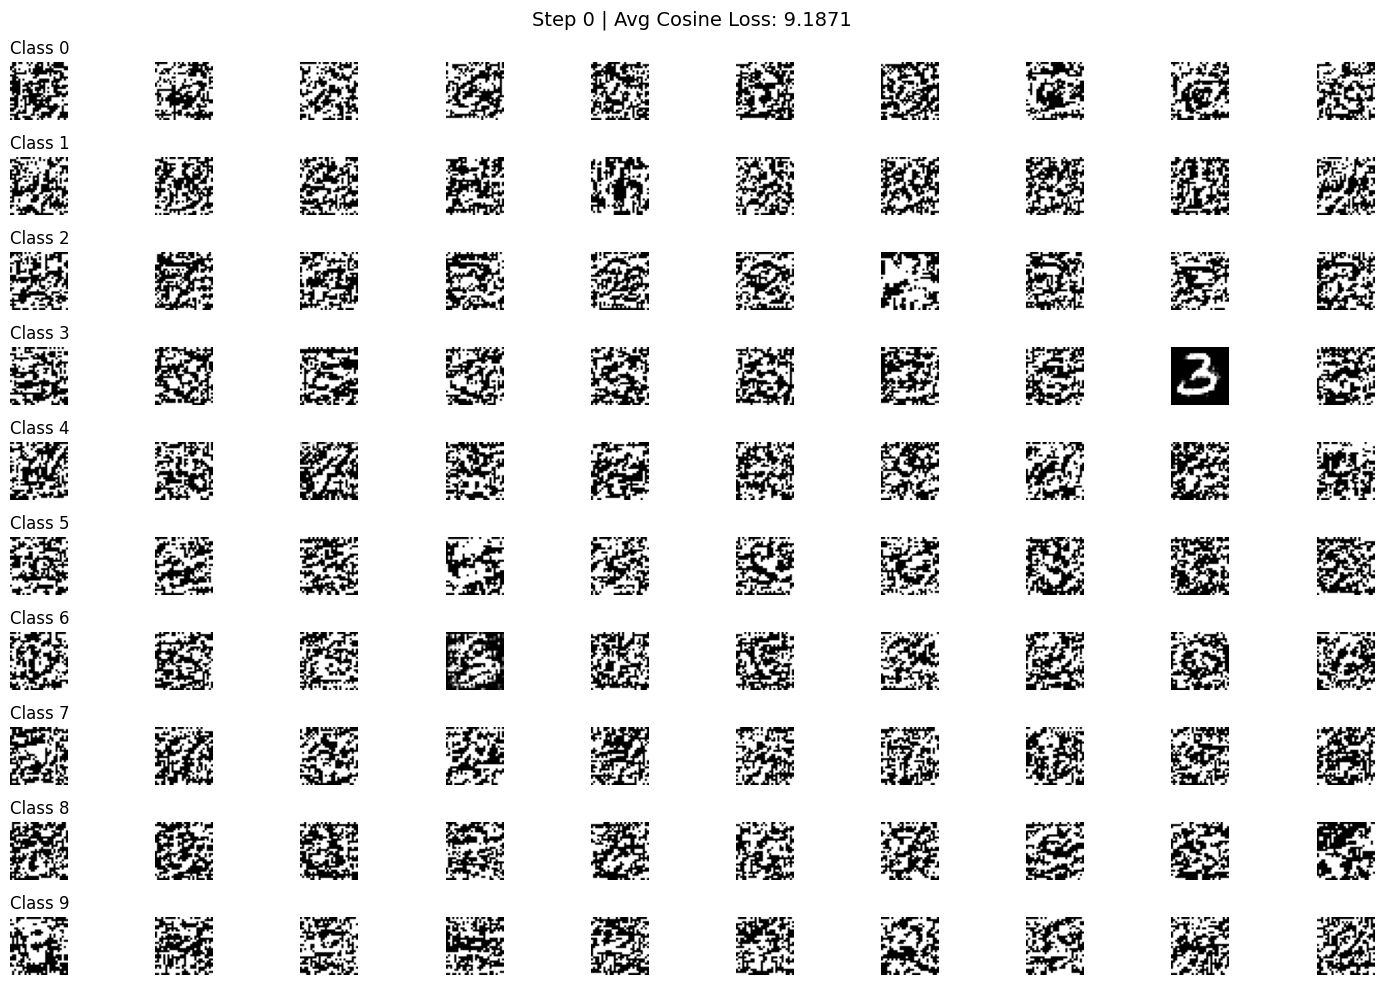

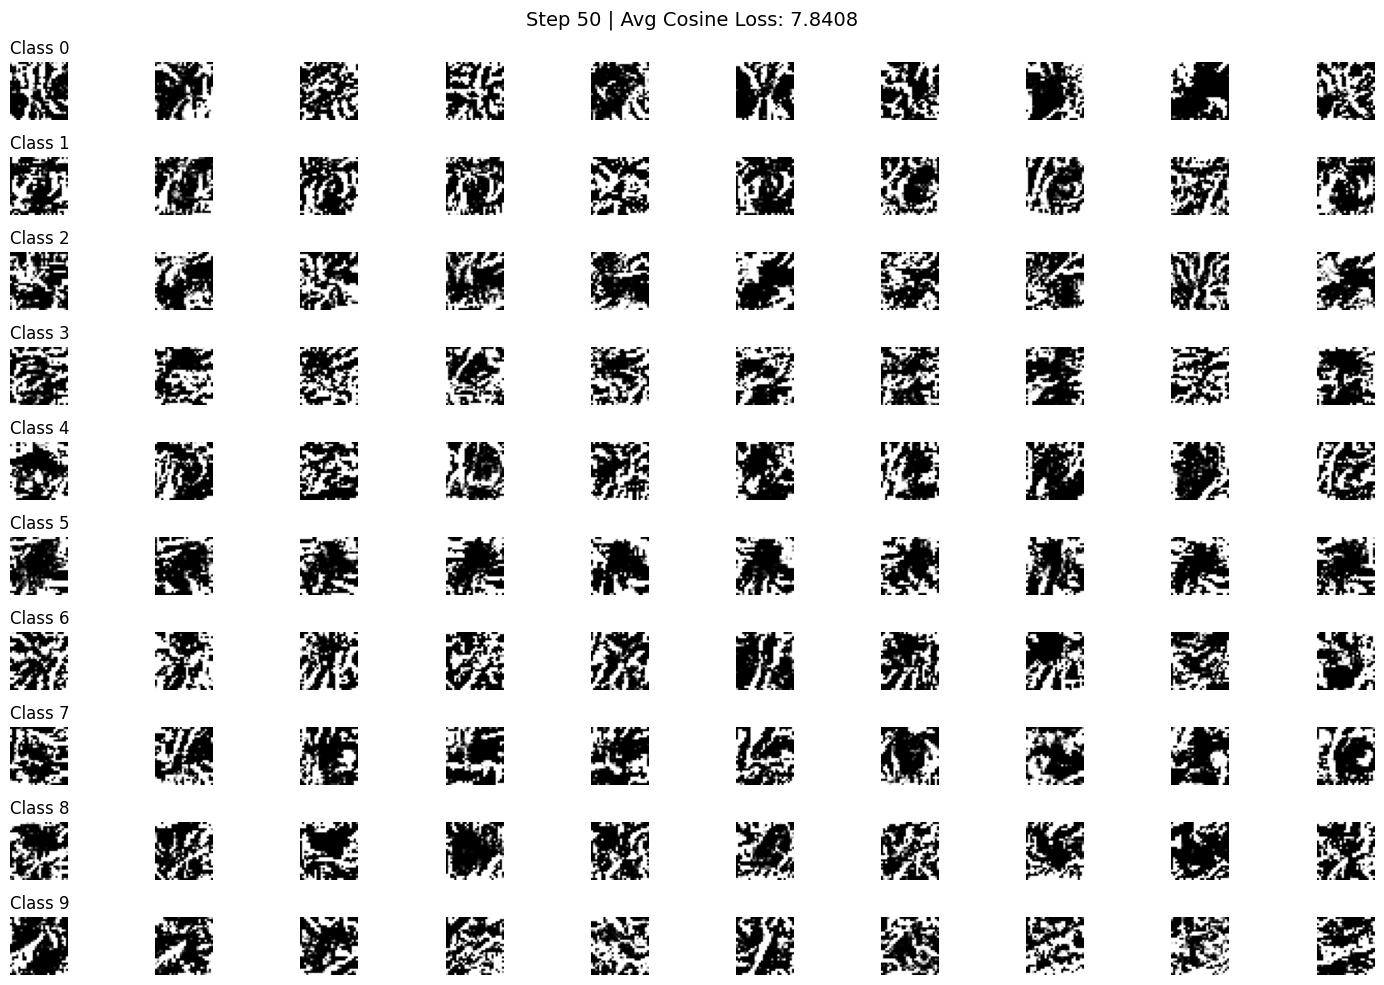

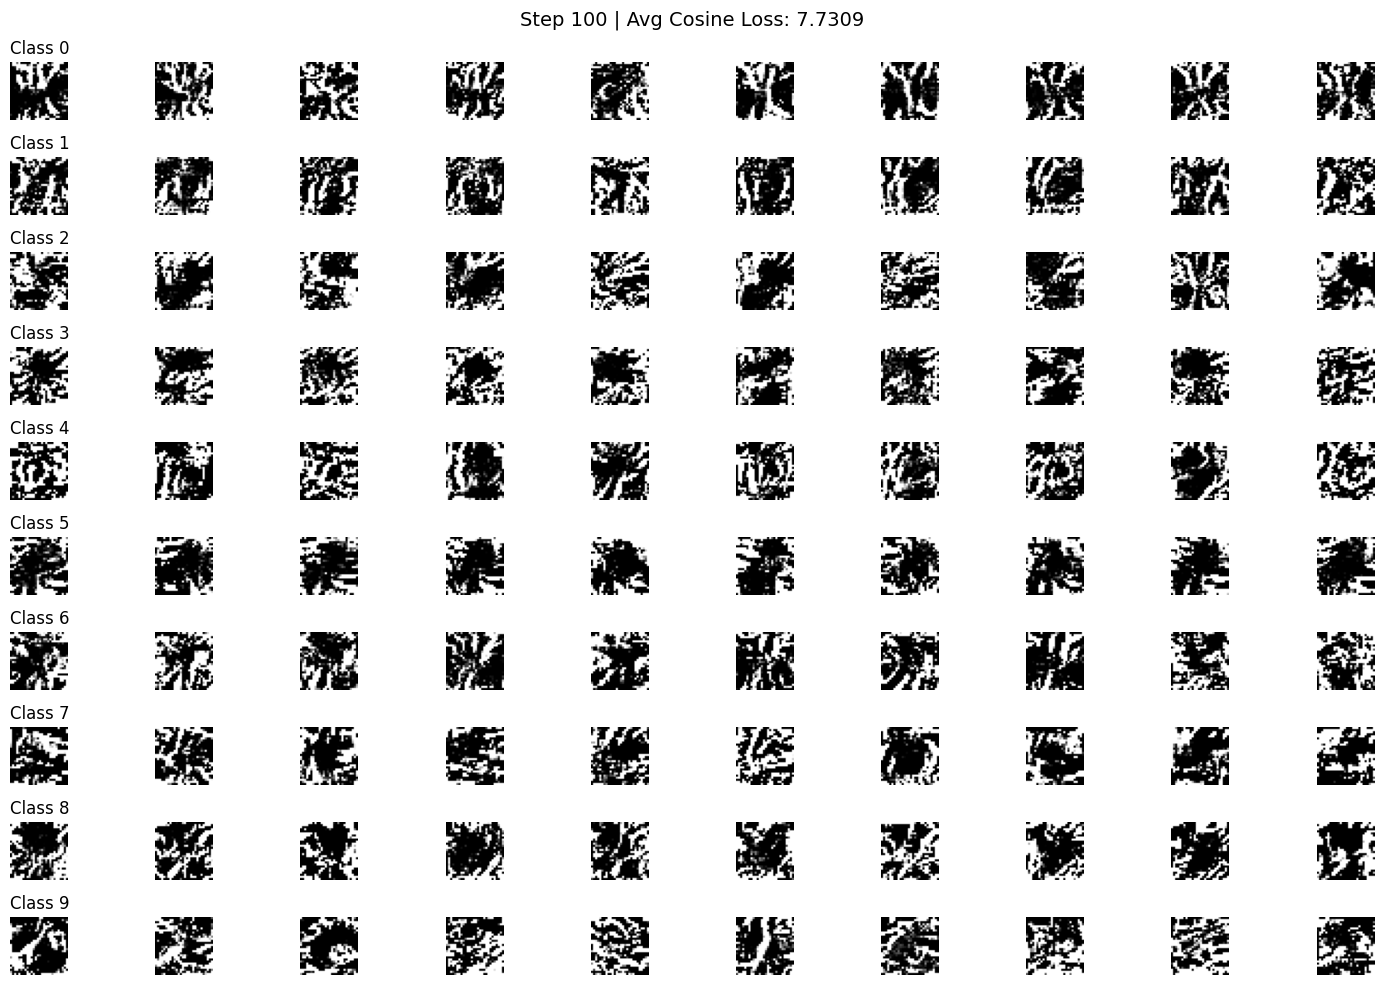

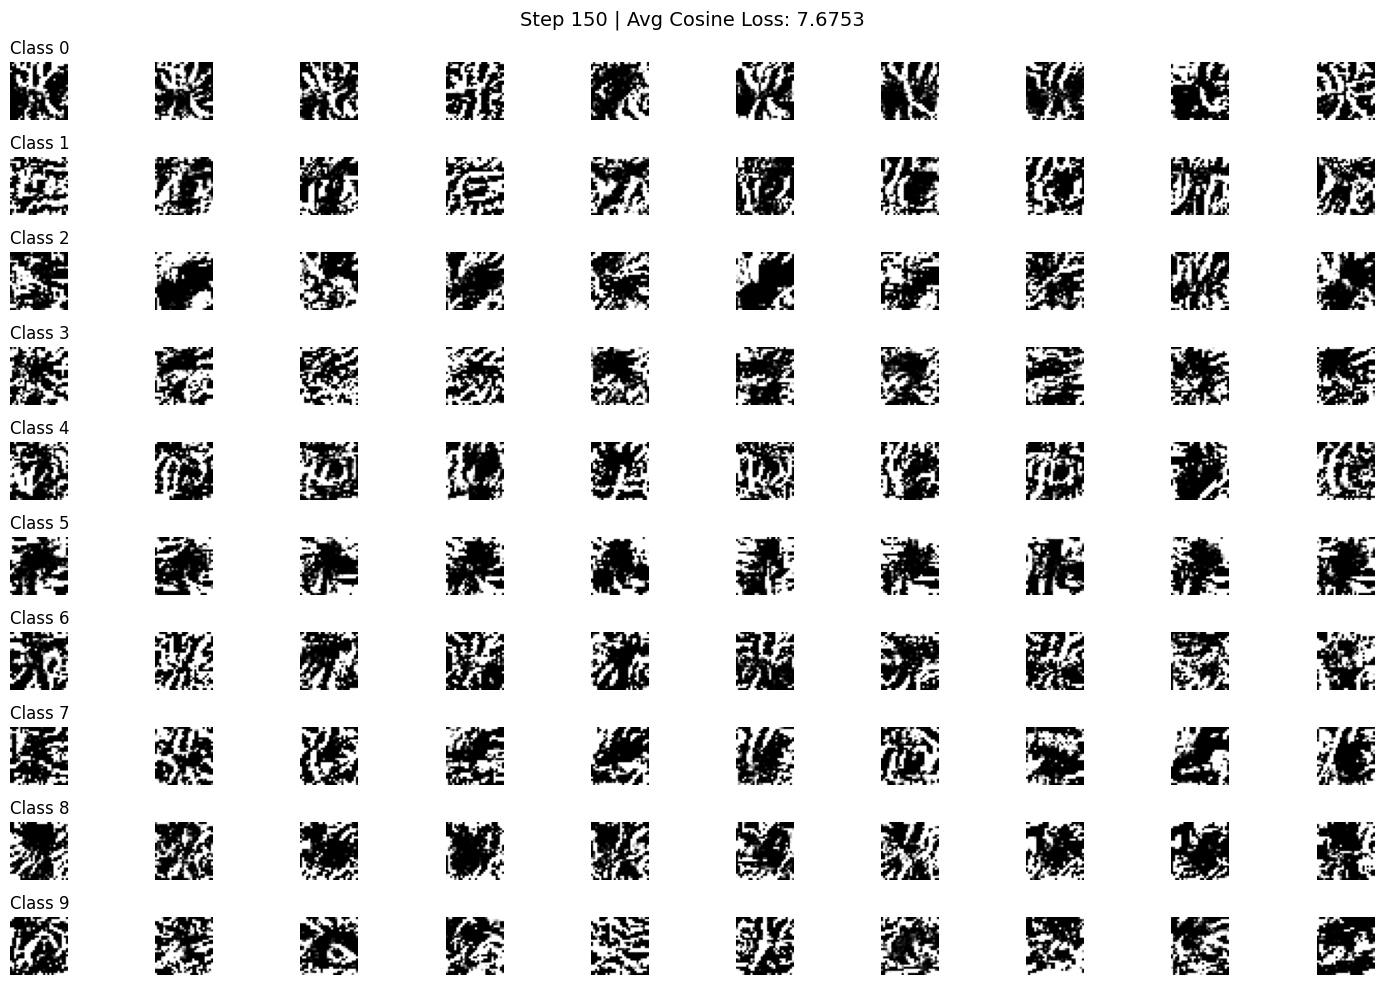

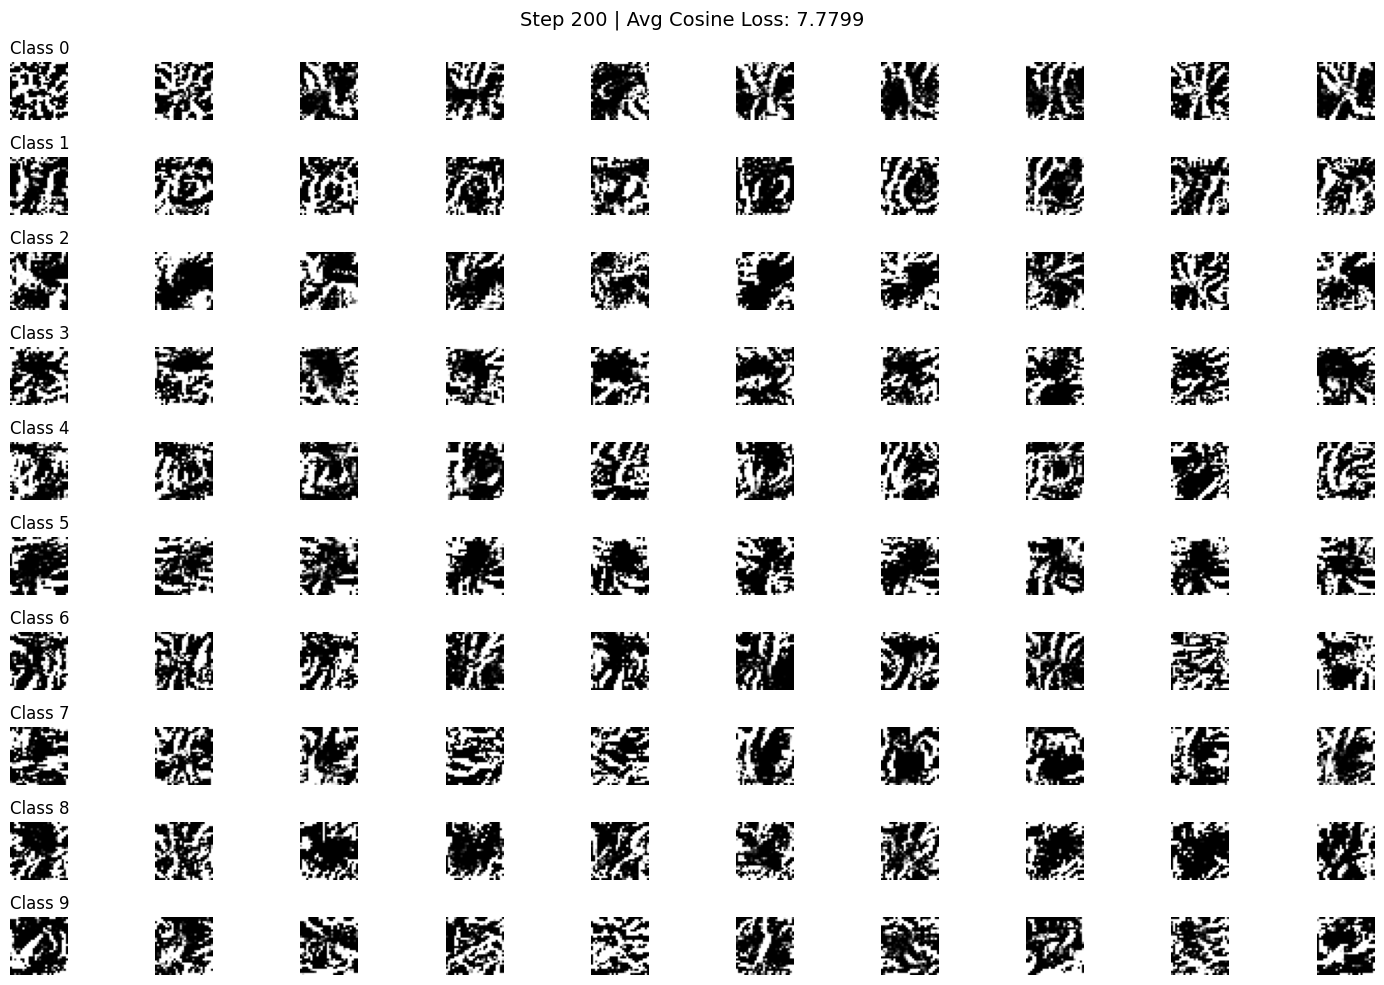

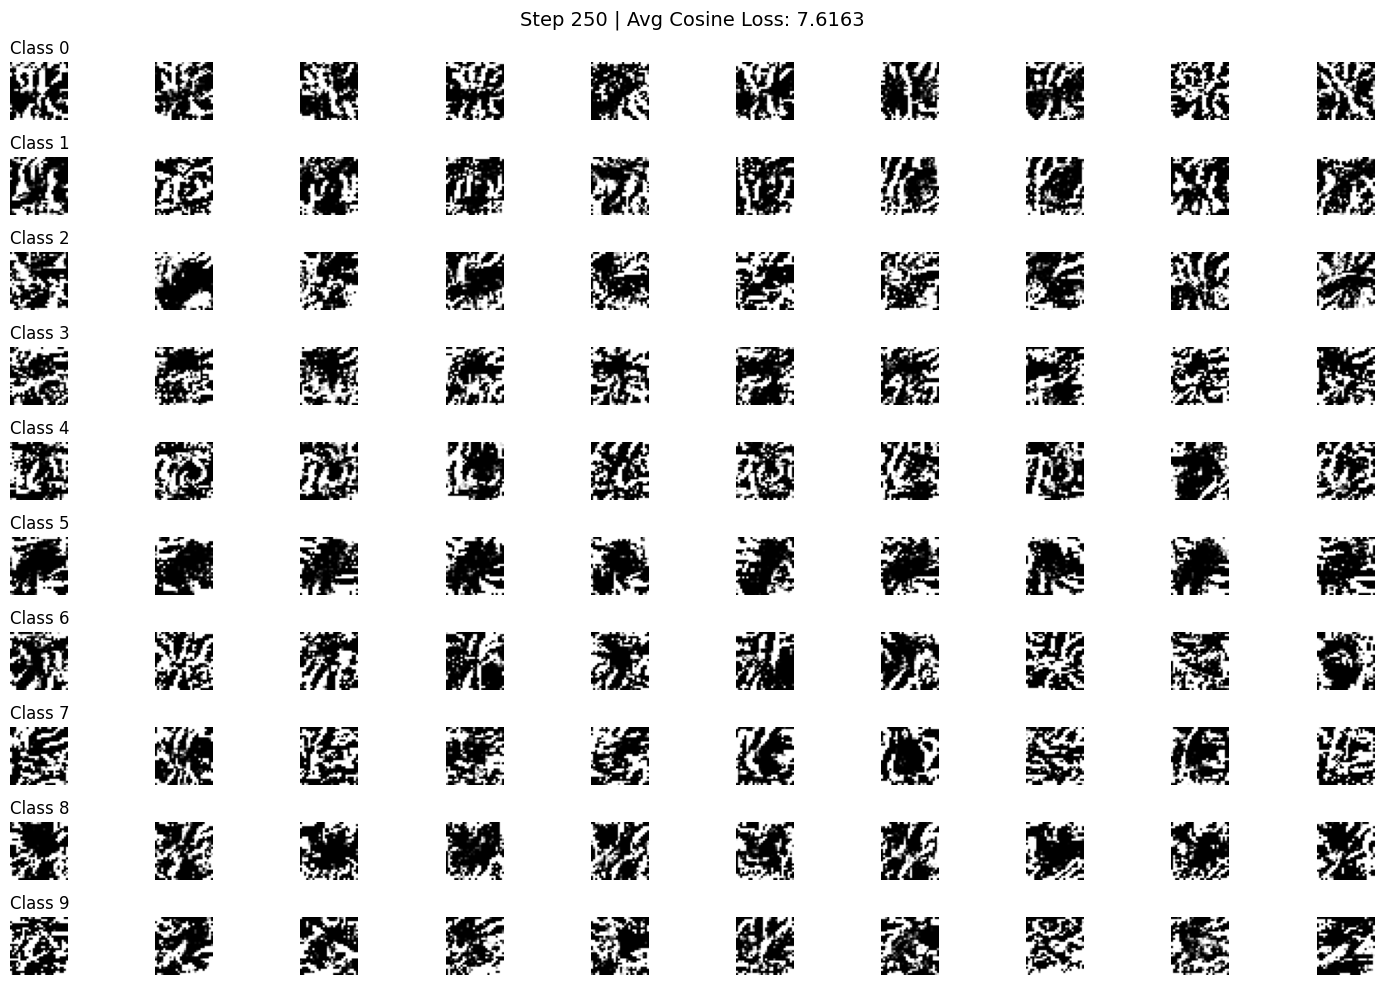

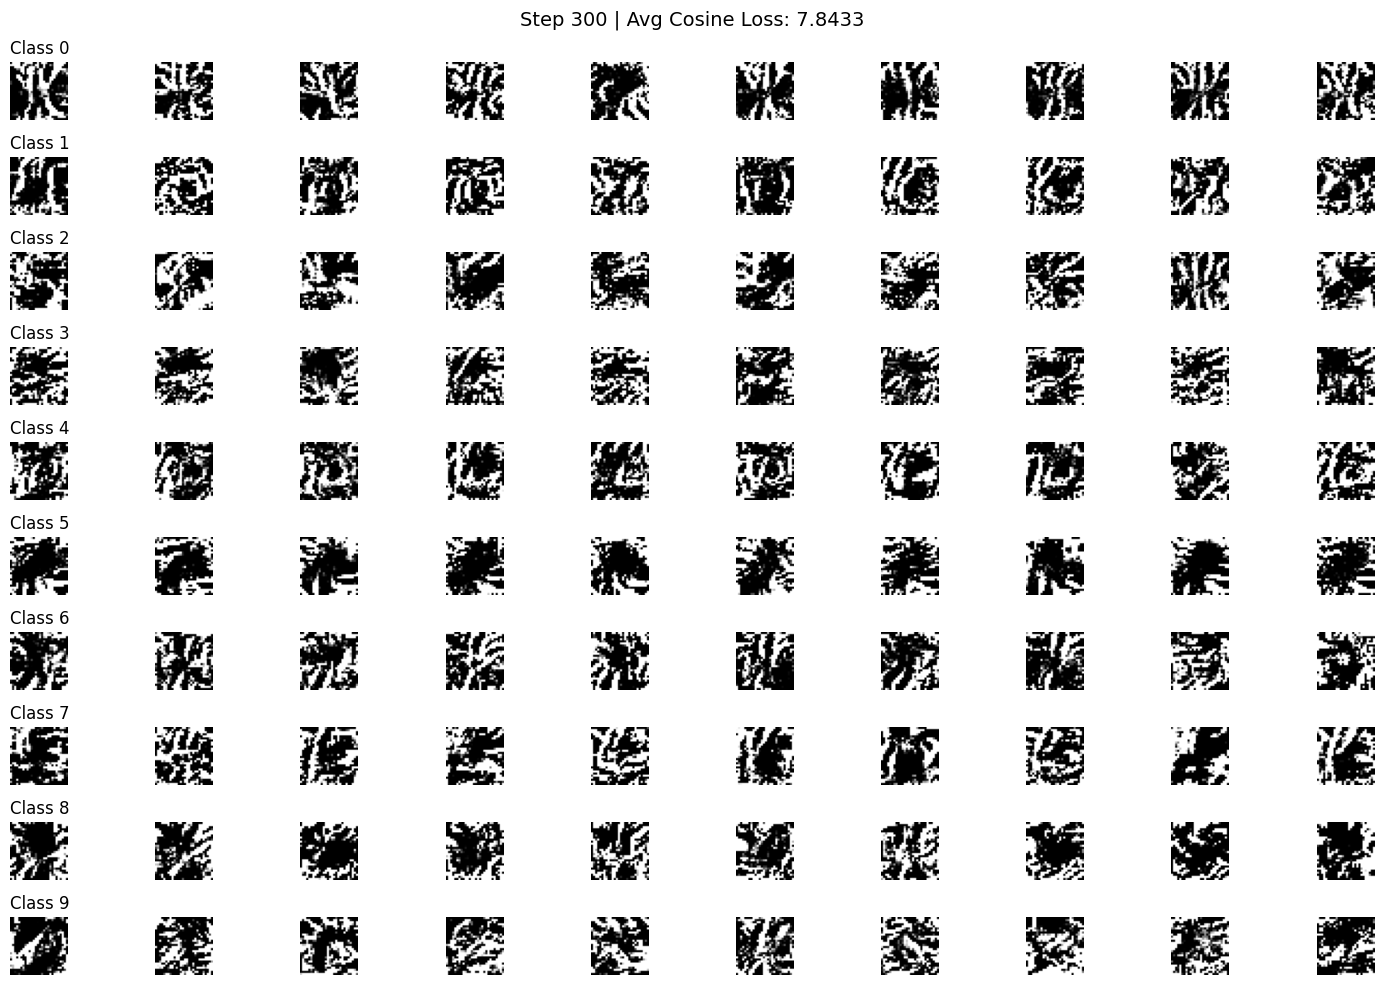

Reverse Gradient Matching took 1626.4777 seconds.


In [32]:
start_time = time.time()
synset = reverse_gradient_matching(trajectory, cluster_assignments, train_set, device)
end_time = time.time()

elapsed_time = end_time - start_time
print(f"Reverse Gradient Matching took {elapsed_time:.4f} seconds.")



In [33]:
# Save updated synthetic dataset
torch.save({'images': synset.synthetic_images.detach().cpu(),
           'labels': synset.synthetic_labels.cpu()}, 
          'reverse_synset.pth')

<ipython-input-49-71e091f5f85b>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synset_data = torch.load("reverse_synset.pth")


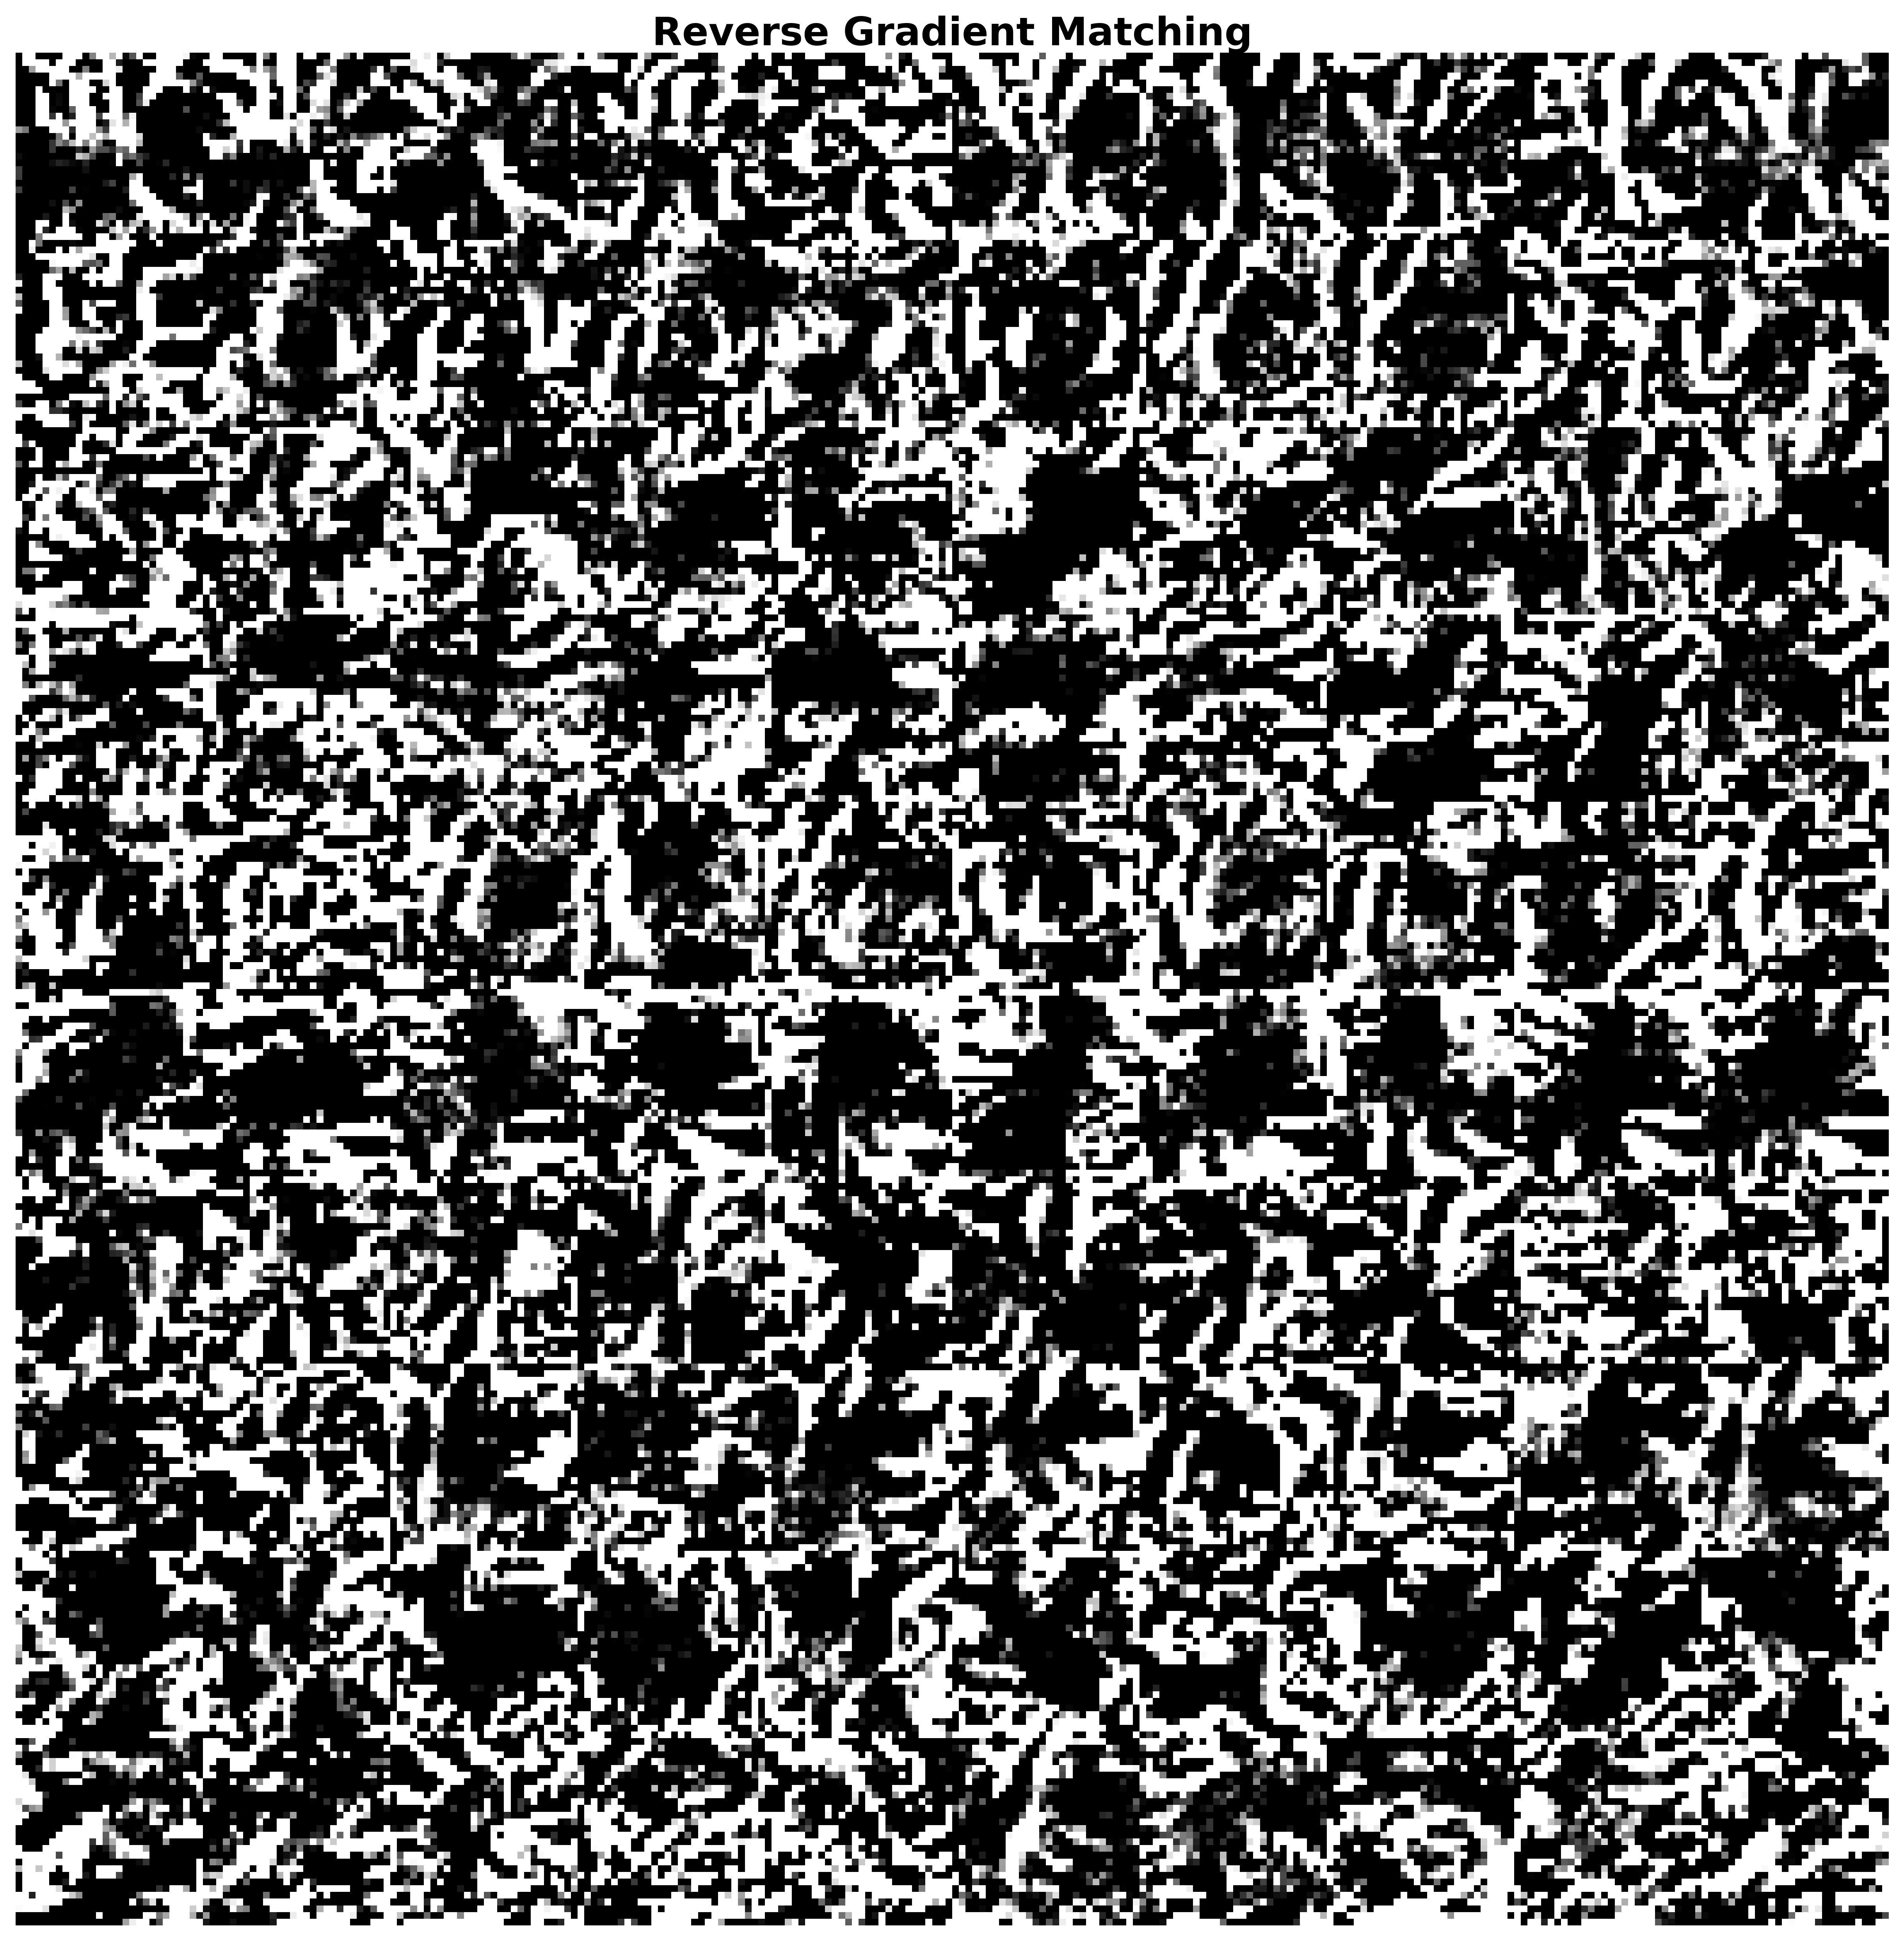

 Final synthetic images saved as 'reverse_gradient_matching_final.png'


In [49]:
synset_data = torch.load("reverse_synset.pth")
synthetic_images = synset_data["images"]

num_classes = 10
num_clusters = synthetic_images.shape[0] // num_classes  

fig, axes = plt.subplots(num_classes, num_clusters, figsize=(12, 12), dpi=400,
                         gridspec_kw={'wspace': 0, 'hspace': 0})
for cls in range(num_classes):
    for clus in range(num_clusters):
        cluster_idx = cls * num_clusters + clus  
        image = synthetic_images[cluster_idx].detach().cpu().numpy().squeeze()

        ax = axes[cls, clus]
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)  
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")  
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
plt.suptitle("Reverse Gradient Matching", fontsize=18, fontweight='bold', y=1.02)
plt.savefig("reverse_gradient_matching_final.png", dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()

print(" Final synthetic images saved as 'reverse_gradient_matching_final.png'")


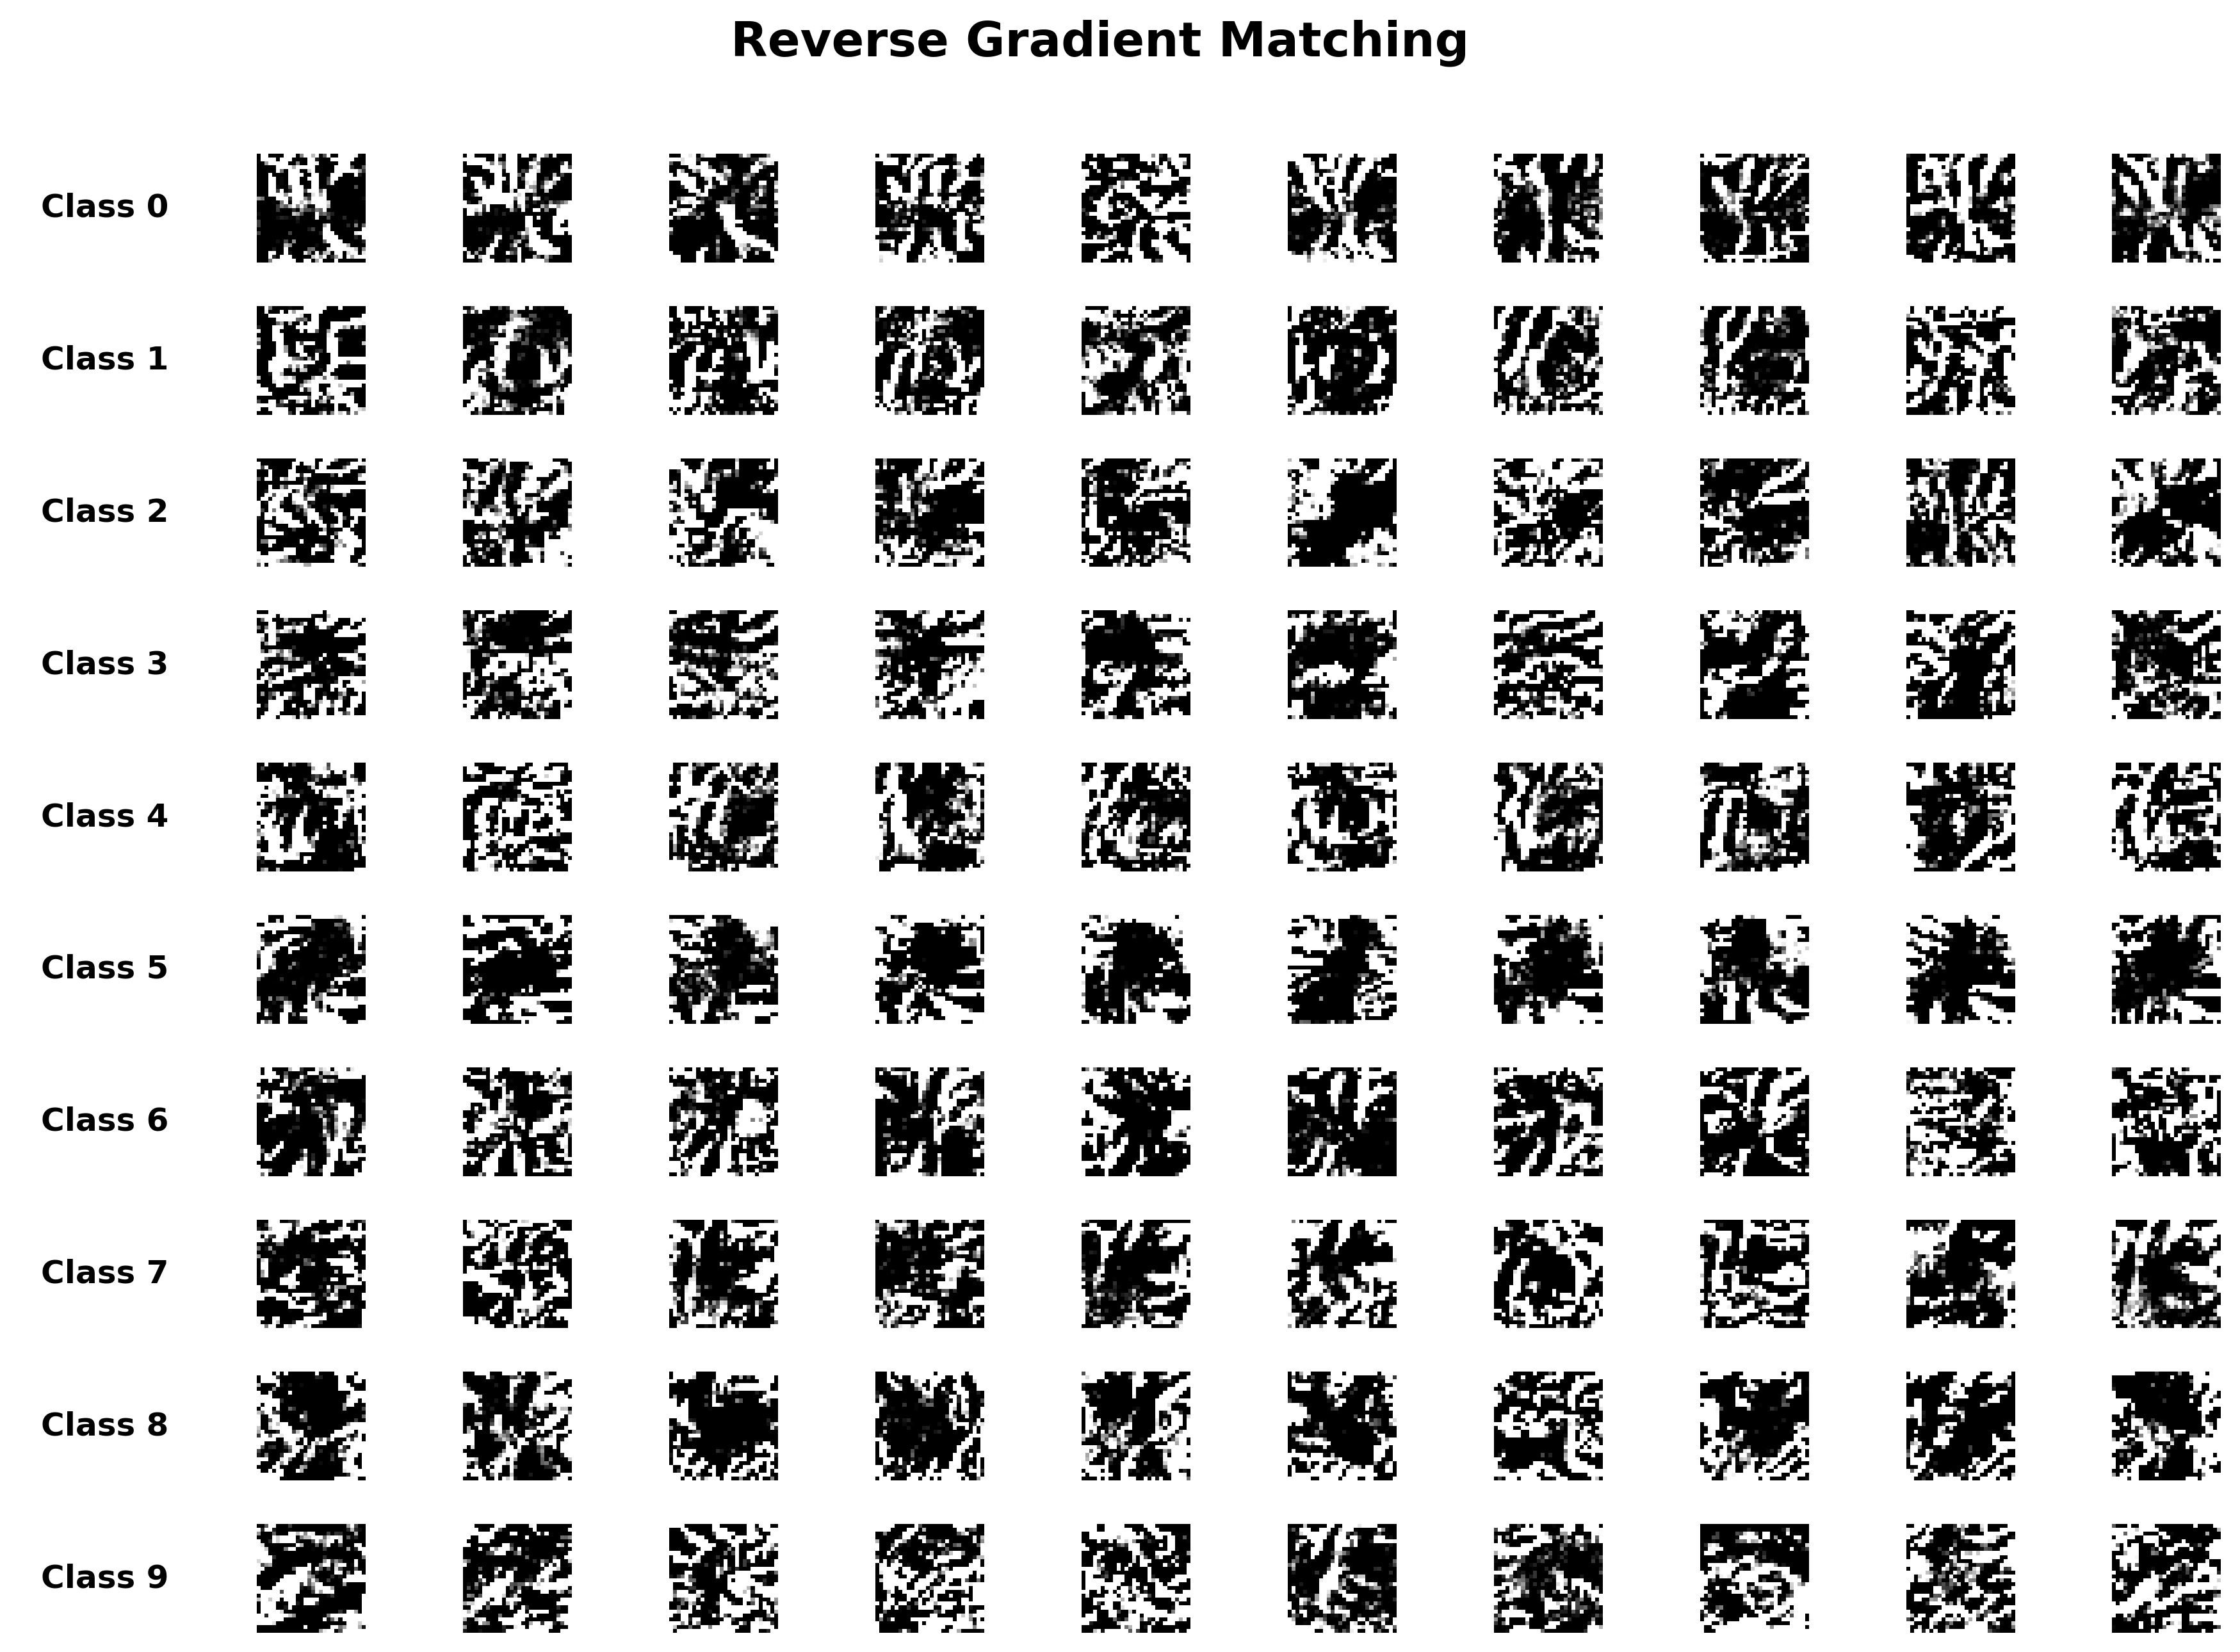

Final synthetic images saved as 'reverse_gradient_matching_final.png'


In [54]:
fig, axes = plt.subplots(num_classes, num_clusters + 1, figsize=(15, 10), dpi=300,
                         gridspec_kw={'wspace': 0.2, 'hspace': 0.4})

for cls in range(num_classes):
    ax_label = axes[cls, 0]
    ax_label.text(0.5, 0.5, f"Class {cls}", fontsize=12, fontweight='bold', ha='center', va='center', rotation=0)
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    ax_label.axis("off") 

    # Plot images for each cluster
    for clus in range(num_clusters):
        cluster_idx = cls * num_clusters + clus 
        image = synthetic_images[cluster_idx].detach().cpu().numpy().squeeze()

        ax = axes[cls, clus + 1]  
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)  
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")

plt.suptitle("Reverse Gradient Matching", fontsize=18, fontweight='bold', y=0.95)
plt.savefig("reverse_gradient_matching_final.png", dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

print("Final synthetic images saved as 'reverse_gradient_matching_final.png'")


## ** Online Evaluation Step**

### **Input**
- `M`: Target model  
- `S`: Synset (synthetic dataset)  
- `xt`: Test sample  

### **Steps**
1. **Generate perturbations** `Pt` randomly.  
2. **For each `pt` in `Pt`**:  
   - Apply perturbation `pt` to `S` → `pt ∘ S`  
   - Fine-tune `M` using `pt ∘ S`  
   - Evaluate fine-tuned model on `xt` to get `~yt`  
3. **Compute the attribution matrix `W`** using Eq. 8.  

### **Output**
- `W`: Attribution matrix quantifying the influence of clusters in `S`.


In [ ]:
# Convert nn.ParameterList to Tensors
synthetic_tensors = []
synthetic_targets = []

for k in range(K):
    # Convert from nn.Parameter and detach from computational graph
    img_tensor = synset.synthetic_images[k].detach() 
    synthetic_tensors.append(img_tensor)
    synthetic_targets.append(
        synset.synthetic_labels[k].item())  

# Stack tensors
synthetic_data = torch.stack(synthetic_tensors, dim=0)  
synthetic_labels = torch.tensor(
    synthetic_targets, dtype=torch.long)  

print(f"Synthetic dataset shape: {synthetic_data.shape}")
print(f"Synthetic labels shape: {synthetic_labels.shape}")  

In [ ]:
syn_dataset = TensorDataset(synthetic_data, synthetic_labels) 
syn_loader = DataLoader(syn_dataset, batch_size=16, shuffle=True)

In [34]:
# ============================
# Generate Perturbations
# ============================
def generate_perturbations(K, num_perturbations=100, sparsity=0.5, device="cuda"):
    """
    Generate a perturbation matrix with sparsity.
    """
    Pt = torch.randint(0, 2, (num_perturbations, K), device=device).float()
    Pt *= (torch.rand_like(Pt) < sparsity).float()  # Apply sparsity
    return Pt

# ============================
# Prepare Synthetic Dataset
# ============================
def prepare_synthetic_data(synset):
    """
    Convert synthetic images and labels into tensors.
    """
    syn_images_tensor = synset.synthetic_images.detach().to(device)  
    syn_labels_tensor = synset.synthetic_labels.clone().detach().to(device)

    return syn_images_tensor, syn_labels_tensor



In [35]:
# ============================
#  Fine-tune the Model with Perturbed Synsets
# ============================
def fine_tune_with_perturbation(trained_model, syn_images, syn_labels, Pt, criterion, num_epochs, device):
    """
    Fine-tune the model using the perturbed synset,1 image per cluster.
    """
    perturbed_models = []
    IPC = 1  

    for pt in Pt:
        model_ft = copy.deepcopy(trained_model).to(device)
        model_ft.load_state_dict(trained_model.state_dict()) 
        optimizer = optim.SGD(model_ft.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)

        #  Remove entire clusters based on perturbation mask
        mask = pt.bool()
        remaining_clusters = torch.arange(Pt.shape[1], device=device)[mask]  
        kept_indices = remaining_clusters.to(device)  

        masked_syn_images = syn_images[kept_indices]  
        masked_syn_labels = syn_labels[kept_indices]

        dataset = TensorDataset(masked_syn_images, masked_syn_labels)
        syn_loader = DataLoader(dataset, batch_size=64, shuffle=True)

        for epoch in range(num_epochs):
            model_ft.train()
            for imgs, lbls in syn_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)

                optimizer.zero_grad()
                outputs = model_ft(imgs)
                loss = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()

        perturbed_models.append(model_ft)

    return perturbed_models


In [36]:
# ============================
# Calculate the Attribution Matrix
# ============================
def calculate_attribution_matrix(perturbed_models, test_samples, Pt):
    """
    Calculate the attribution matrix W using Ridge Regression.
    """
    X = Pt.cpu().numpy()
    y = []

    for model in perturbed_models:
        model.eval()
        with torch.no_grad():
            outputs = [model(x.unsqueeze(0).to(device)).cpu().numpy().squeeze() for x in test_samples]
            y.append(np.mean(outputs, axis=0))  

    y = np.array(y)
    W = Ridge(alpha=1e-3).fit(X, y).coef_  
    return W

# ============================
# Compute Influence Metrics
# ============================
def compute_metrics(perturbed_models, unlearn_model, test_samples, ground_truth_labels):
    """
    Compute influence metrics using all fine-tuned models.
    """
    dist1, dist2, dist3 = [], [], []

    for fine_tuned_model in perturbed_models:
        for xt, yt in zip(test_samples, ground_truth_labels):
            xt = (xt - 0.1307) / 0.3081  
            xt = xt.unsqueeze(0).to(device)  
            yt = torch.tensor(yt, dtype=torch.long, device=device)

            with torch.no_grad():
                y_tilde = fine_tuned_model(xt)
                y_unlearn = unlearn_model(xt)

            y_tilde = F.softmax(y_tilde, dim=1)
            y_unlearn = F.softmax(y_unlearn, dim=1)

            diff = y_unlearn - y_tilde
            dist1.append(torch.norm(diff, p=2, dim=1).mean().item())
            dist2.append(F.cross_entropy(y_unlearn, yt.unsqueeze(0)).item())  
            dist3.append(1 / (1 + torch.norm(diff, p=2, dim=1).mean().item()))  

    return np.mean(dist1), np.mean(dist2), np.mean(dist3)


In [45]:
# ============================
# Online Evaluation Process
# ============================

print("Generating perturbations...")
num_perturbations = 100
K = 100  
Pt = generate_perturbations(K, num_perturbations=num_perturbations, sparsity=0.5, device=device)

print(f"Generated {num_perturbations} perturbations with sparsity 0.5.")

syn_images_tensor, syn_labels_tensor = prepare_synthetic_data(synset)

# Fine-tune models with perturbed synsets
print("Fine-tuning the model with perturbed synsets...")
perturbed_models = fine_tune_with_perturbation(
    trained_model=model, 
    syn_images=syn_images_tensor,
    syn_labels=syn_labels_tensor,
    Pt=Pt,
    criterion=torch.nn.CrossEntropyLoss(),
    num_epochs=5,
    device=device,
)

#  Compute Influence Metrics for Multiple Test Samples
num_test_samples = 20  
test_indices = np.random.choice(len(test_loader.dataset), num_test_samples, replace=False)
test_samples = [test_loader.dataset[i][0] for i in test_indices] 
ground_truth_labels = [test_loader.dataset[i][1] for i in test_indices] 

print("\nEvaluating influence metrics for multiple test samples...")

# Compute Attribution Matrix using all test samples
W = calculate_attribution_matrix(perturbed_models, test_samples, Pt)

# Compute Influence Metrics using all test samples
avg_dist1, avg_dist2, avg_dist3 = compute_metrics(
    perturbed_models,  
    model,  
    test_samples,  
    ground_truth_labels,  
)

print(f"\n Avg Influence Across {num_test_samples} Test Samples:")
print(f"   AvgDist1 (L2): {avg_dist1*100:.4f}")
print(f"   AvgDist2 (Cross-Entropy): {avg_dist2:.4f}")
print(f"   AvgDist3 (Inverse L2): {avg_dist3:.4f}")

Generating perturbations...
Generated 100 perturbations with sparsity 0.5.
Fine-tuning the model with perturbed synsets...

Evaluating influence metrics for multiple test samples...

 Avg Influence Across 20 Test Samples:
   AvgDist1 (L2): 10.5363
   AvgDist2 (Cross-Entropy): 1.4612
   AvgDist3 (Inverse L2): 0.9529


# Generated Synset Dataset Evaluation

In [102]:
def evaluate_model(model, test_loader, device):
    """
    Evaluate a model on the test set and return accuracy.
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    accuracy = 100 * correct / total
    return accuracy


original_accuracy = evaluate_model(model, test_loader, device)
print(f"Original Model (Trained on Real Data) - Accuracy: {original_accuracy:.2f}% | Training Time: {total_time:.2f} sec")


# Train Model from Scratch on Synthetic Dataset
def train_model(model, train_loader, num_epochs, learning_rate, device):
    """
    Train a model on the given dataset and return test accuracy & training time.
    """
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    
    start_time = time.time()  # Track time

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

    total_time = time.time() - start_time  # Total training time
    return model, total_time

print("\nTraining from scratch on the synthetic dataset...")
scratch_model = ConvNet(num_classes=10)
scratch_model, synthetic_time = train_model(scratch_model, syn_loader, num_epochs=3, learning_rate=0.005, device=device)
scratch_accuracy = evaluate_model(scratch_model, test_loader, device)

print(f"Scratch Model (Synthetic Data) - Accuracy: {scratch_accuracy:.2f}% | Training Time: {synthetic_time:.2f} sec")

# Fine-Tune Original Model on Synthetic Dataset

print("\nFine-tuning the original model using synthetic data...")
finetune_model = copy.deepcopy(model)  # Start with the pretrained model
finetune_model, finetune_time = train_model(finetune_model, syn_loader, num_epochs=3, learning_rate=0.005, device=device)
finetune_accuracy = evaluate_model(finetune_model, test_loader, device)

print(f" Fine-Tuned Model (Synthetic Data) - Accuracy: {finetune_accuracy:.2f}% | Training Time: {finetune_time:.2f} sec")

#  Summary of Results
print("\n Final Comparison:")
print(f"Original Model (Real Data) - Accuracy: {original_accuracy:.2f}% | Training Time: {total_time:.2f} sec")
print(f"Scratch Model (Synthetic Data) - Accuracy: {scratch_accuracy:.2f}% | Training Time: {synthetic_time:.2f} sec")
print(f"Fine-Tuned Model (Synthetic Data) - Accuracy: {finetune_accuracy:.2f}% | Training Time: {finetune_time:.2f} sec")


Original Model (Trained on Real Data) - Accuracy: 99.35% | Training Time: 273.58 sec

Training from scratch on the synthetic dataset...
Epoch [1/3] - Loss: 2.3076
Epoch [2/3] - Loss: 2.3041
Epoch [3/3] - Loss: 2.2857
Scratch Model (Synthetic Data) - Accuracy: 10.37% | Training Time: 0.04 sec

Fine-tuning the original model using synthetic data...
Epoch [1/3] - Loss: 3.2163
Epoch [2/3] - Loss: 2.3343
Epoch [3/3] - Loss: 2.2739
 Fine-Tuned Model (Synthetic Data) - Accuracy: 83.25% | Training Time: 0.04 sec

 Final Comparison:
Original Model (Real Data) - Accuracy: 99.35% | Training Time: 273.58 sec
Scratch Model (Synthetic Data) - Accuracy: 10.37% | Training Time: 0.04 sec
Fine-Tuned Model (Synthetic Data) - Accuracy: 83.25% | Training Time: 0.04 sec


In [114]:
print("\n Computing Attribution Matrix...")

# Compute Influence Scores
num_test_samples = 20  
test_indices = np.random.choice(len(test_loader.dataset), num_test_samples, replace=False)
test_samples = [test_loader.dataset[i][0] for i in test_indices]  

# Compute Attribution Matrix `W`
W = calculate_attribution_matrix(perturbed_models, test_samples, Pt)

# Use Mean Absolute Influence Score 
sample_influence = np.mean(np.abs(W), axis=0)  
sorted_sample_indices = np.argsort(sample_influence)  

# Remove Clusters
K = len(syn_images_tensor)  
clusters_per_sample = K // len(W[0])  
sorted_cluster_indices = sorted_sample_indices // clusters_per_sample  

print("Least influential clusters:", sorted_cluster_indices[:10])

# Define Removal Percentages & Initialize Results
removal_percentages = [0, 1, 10, 20, 50]  
ddm_accuracies = []

# Fine-Tune Model with Reduced Synthetic Data
for percentage in removal_percentages:
    print(f"\n Fine-tuning with {percentage}% of least influential synthetic training clusters removed...")

    # Fine-Tuning Starts from Fully Trained Model
    fine_tuned_model = copy.deepcopy(model).to(device)
    fine_tuned_model.load_state_dict(model.state_dict())  

    # Number of Clusters to Remove
    num_clusters_to_remove = int(len(sorted_cluster_indices) * (percentage / 100))
    kept_clusters = sorted_cluster_indices[num_clusters_to_remove:]  # Keep influential clusters

    print(f"Clusters Removed: {num_clusters_to_remove} | Clusters Remaining: {len(kept_clusters)}")
    print(f"Least influential clusters removed: {sorted_cluster_indices[:num_clusters_to_remove]}")

    # Prepare Reduced Synthetic Dataset
    kept_samples = np.concatenate([np.arange(c * clusters_per_sample, (c + 1) * clusters_per_sample) for c in kept_clusters])
    reduced_syn_images = syn_images_tensor[kept_samples]
    reduced_syn_labels = syn_labels_tensor[kept_samples]

    print(f"Fine-tuning with {percentage}% removed → Remaining Samples: {reduced_syn_images.shape[0]}")

    # Convert to DataLoader
    dataset = TensorDataset(reduced_syn_images, reduced_syn_labels)
    reduced_loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # Fine-Tune the Model
    num_epochs = 5  
    optimizer = optim.SGD(fine_tuned_model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        fine_tuned_model.train()
        for imgs, lbls in reduced_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            outputs = fine_tuned_model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

    # Evaluate on MNIST Original Test Set
    accuracy = evaluate_model(fine_tuned_model, test_loader, device) 
    ddm_accuracies.append(accuracy)

table_3_data = {
    "Percentage Removed (%)": removal_percentages,
    "Acc": ddm_accuracies,
}

df_table_3 = pd.DataFrame(table_3_data)

print("\n Detecting useless training data for the target network:")
print(df_table_3)



 Computing Attribution Matrix...
Least influential clusters: [78 71 87 74 12 47 15 17 89 11]

 Fine-tuning with 0% of least influential synthetic training clusters removed...
Clusters Removed: 0 | Clusters Remaining: 100
Least influential clusters removed: []
Fine-tuning with 0% removed → Remaining Samples: 100

 Fine-tuning with 1% of least influential synthetic training clusters removed...
Clusters Removed: 1 | Clusters Remaining: 99
Least influential clusters removed: [78]
Fine-tuning with 1% removed → Remaining Samples: 99

 Fine-tuning with 10% of least influential synthetic training clusters removed...
Clusters Removed: 10 | Clusters Remaining: 90
Least influential clusters removed: [78 71 87 74 12 47 15 17 89 11]
Fine-tuning with 10% removed → Remaining Samples: 90

 Fine-tuning with 20% of least influential synthetic training clusters removed...
Clusters Removed: 20 | Clusters Remaining: 80
Least influential clusters removed: [78 71 87 74 12 47 15 17 89 11 96 65  1 33 66 81 98

In [116]:
# Define Model Architectures


# AlexNet
class AlexNetMNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetMNIST, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


alexnet_mnist = AlexNetMNIST().to(device)

# ResNet-18 
class ResNet18MNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18MNIST, self).__init__()
        self.resnet18 = models.resnet18(pretrained=False)
        self.resnet18.conv1 = nn.Conv2d(
            1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet18.maxpool = nn.Identity()
        self.resnet18.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.resnet18(x)


resnet18_mnist = ResNet18MNIST().to(device)

# Vision Transformer
class ViT_MNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(ViT_MNIST, self).__init__()
        self.vit = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=False,
            img_size=28,
            in_chans=1,
            num_classes=num_classes,
            patch_size=4,
        )
        self.vit.set_grad_checkpointing(enable=True)

    def forward(self, x):
        return self.vit(x)


vit_mnist = ViT_MNIST().to(device)

# Store all models in a dictionary
models_dict = {"AlexNet": alexnet_mnist,
               "ResNet18": resnet18_mnist, "ViT": vit_mnist}


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [117]:
# Train Models
def train_model(model, train_loader, num_epochs=10, model_name=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += loss.item()

        print(
            f"[{model_name}] Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

    return model


torch.cuda.empty_cache()
gc.collect()

# Train all models
for name, model in models_dict.items():
    print(f"\n Training {name} on MNIST...")
    models_dict[name] = train_model(
        model, train_loader, num_epochs=10, model_name=name)

print("\n Training Complete!")


 Training AlexNet on MNIST...


<ipython-input-117-346c40117e1e>:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
<ipython-input-117-346c40117e1e>:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[AlexNet] Epoch 1/10, Loss: 0.1559
[AlexNet] Epoch 2/10, Loss: 0.0537
[AlexNet] Epoch 3/10, Loss: 0.0399
[AlexNet] Epoch 4/10, Loss: 0.0301
[AlexNet] Epoch 5/10, Loss: 0.0297
[AlexNet] Epoch 6/10, Loss: 0.0262
[AlexNet] Epoch 7/10, Loss: 0.0189
[AlexNet] Epoch 8/10, Loss: 0.0194
[AlexNet] Epoch 9/10, Loss: 0.0174
[AlexNet] Epoch 10/10, Loss: 0.0140

 Training ResNet18 on MNIST...
[ResNet18] Epoch 1/10, Loss: 0.1267
[ResNet18] Epoch 2/10, Loss: 0.0357
[ResNet18] Epoch 3/10, Loss: 0.0266
[ResNet18] Epoch 4/10, Loss: 0.0211
[ResNet18] Epoch 5/10, Loss: 0.0193
[ResNet18] Epoch 6/10, Loss: 0.0129
[ResNet18] Epoch 7/10, Loss: 0.0104
[ResNet18] Epoch 8/10, Loss: 0.0111
[ResNet18] Epoch 9/10, Loss: 0.0094
[ResNet18] Epoch 10/10, Loss: 0.0073

 Training ViT on MNIST...


/usr/local/lib/python3.10/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


[ViT] Epoch 1/10, Loss: 1.3493
[ViT] Epoch 2/10, Loss: 0.4095
[ViT] Epoch 3/10, Loss: 0.2196
[ViT] Epoch 4/10, Loss: 0.1532
[ViT] Epoch 5/10, Loss: 0.1216
[ViT] Epoch 6/10, Loss: 0.1008
[ViT] Epoch 7/10, Loss: 0.0925
[ViT] Epoch 8/10, Loss: 0.0741
[ViT] Epoch 9/10, Loss: 0.0657
[ViT] Epoch 10/10, Loss: 0.0621

 Training Complete!


In [118]:
# Save all trained models
save_path = "all_trained_models.pth"
torch.save({name: model.state_dict() for name, model in models_dict.items()}, save_path)
print(f"\n All models saved successfully to {save_path}!")



 All models saved successfully to all_trained_models.pth!


## Comparison of the training data attribution weights calculated form different network architectures.

In [141]:
if isinstance(test_samples, list):
    test_samples = torch.stack(test_samples)

# Fine-Tune Models
attribution_matrices = {}

for name, model in models_dict.items():
    print(f"\n🔄 Fine-Tuning {name}")

    # Fine-tune and store only one model at a time
    fine_tuned_model = fine_tune_with_perturbation(
        trained_model=model,
        syn_images=syn_images_tensor.to(device),
        syn_labels=syn_labels_tensor.to(device),
        Pt=Pt.to(device),
        criterion=torch.nn.CrossEntropyLoss(),
        num_epochs=5,
        device=device,
    )
    test_sample_expanded = test_samples.unsqueeze(0).to(device)

    # Compute Attribution Matrix
    print(f"📊 Calculating Attribution for {name}...")
    attribution_matrices[name] = calculate_attribution_matrix(
        fine_tuned_model,
        test_samples.to(device),
        Pt.to(device)
    )

    # Clean up memory
    del fine_tuned_model
    torch.cuda.empty_cache()

# Convert the attribution matrices to a DataFrame
df = pd.DataFrame({name: np.ravel(W)
                  for name, W in attribution_matrices.items()})
df.index.name = 'Cluster'

print("\n✅ Cluster-wise Attribution Matrix:")
print(df.head(10))


🔄 Fine-Tuning AlexNet...
📊 Calculating Attribution for AlexNet...

🔄 Fine-Tuning ResNet18...
📊 Calculating Attribution for ResNet18...

✅ Cluster-wise Attribution Matrix:
          AlexNet  ResNet18
Cluster                    
0       -0.445811  0.906405
1        0.731834  0.678778
2       -1.010550 -0.109746
3        1.428125  0.418905
4        1.147547  0.923522
5        0.054373  2.270955
6       -0.844634  0.078318
7       -0.427592  0.458147
8        1.680784  0.657405
9        0.222650  1.701371


Shape of AlexNet Attribution Matrix: (10, 100)
Shape of ResNet18 Attribution Matrix: (10, 100)


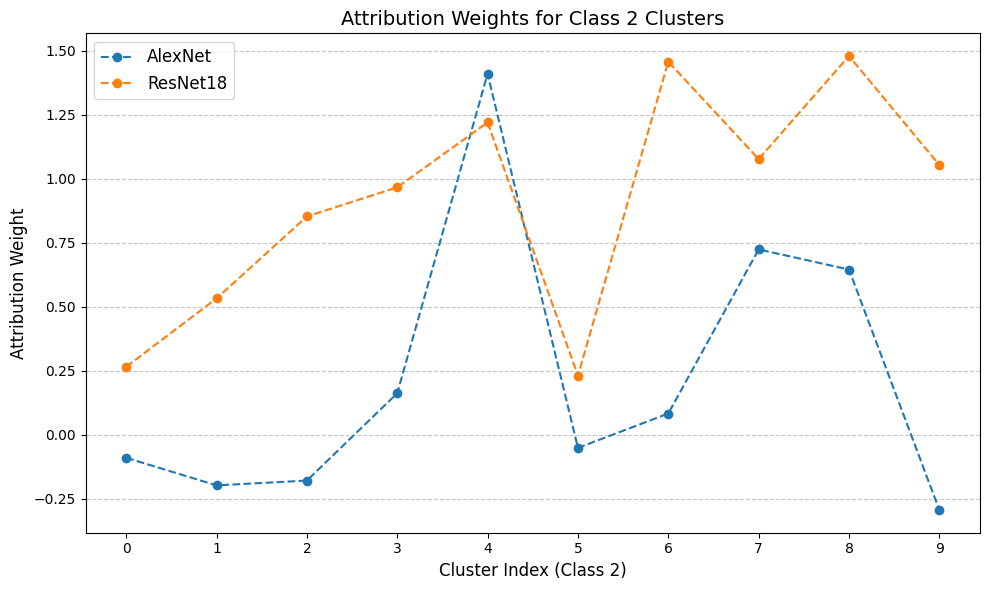

In [135]:
# Visualize Attribution Weights for Class 2 Clusters Only
def visualize_class_2_clusters(attribution_matrices, test_sample_label=2, clusters_per_class=10):
    plt.figure(figsize=(10, 6))

    for name, W in attribution_matrices.items():
        # Validate matrix shape
        print(f"Shape of {name} Attribution Matrix: {W.shape}")
        if W.shape[1] % 10 != 0:  # Assume 10 clusters per class
            raise ValueError(f"Unexpected attribution matrix shape for {name}: {W.shape}")

        # Focus on class 2's clusters
        start_idx = test_sample_label * clusters_per_class
        end_idx = start_idx + clusters_per_class
        cluster_weights = W[test_sample_label, start_idx:end_idx]

        # Plot the cluster weights
        plt.plot(range(clusters_per_class), cluster_weights, marker='o',linestyle = '--', label=name)

    # Add chart details
    plt.title(f"Attribution Weights for Class 2 Clusters", fontsize=14)
    plt.xlabel("Cluster Index (Class 2)", fontsize=12)
    plt.ylabel("Attribution Weight", fontsize=12)
    plt.xticks(range(clusters_per_class), fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("attribution_weights_class2.png", dpi=300)
    plt.show()

# Call the visualization
visualize_class_2_clusters(attribution_matrices, test_sample_label=2, clusters_per_class=10)


In [ ]:
#Step-1

pip install nbconvert
python -m pip install -U notebook-as-pdf
pyppeteer-install

#Step-2

brew install pandoc

#Step-3

brew install chromium

#Step-4
#Just make sure

pip install PyPDF2==2.1.2



: 